# Fraud Detection in transactions (Financial Data)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
creditcard_df = pd.read_csv("../creditcard.csv")

In [3]:
creditcard_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
creditcard_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

### Class Distribution

In [5]:
creditcard_df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [6]:
creditcard_df.shape

(284807, 31)

In [7]:
class_imbalance = creditcard_df["Class"].value_counts(normalize=True).mul(100).reset_index().assign(color = lambda x:np.where(x["Class"].eq(1),"#280B66","#808080"))
class_imbalance["Class"] = class_imbalance["Class"].map({
    0: "Legitimate",
    1: "Fraud"
})

As you can see the distribution of the target variable (Class) reveals a severe class imbalance in the dataset.

In [8]:
creditcard_df["Class"].value_counts()


Class
0    284315
1       492
Name: count, dtype: int64

In [9]:
print("Precentage of each class in the dataset:")
class_imbalance

Precentage of each class in the dataset:


,Class,proportion,color
0,Legitimate,99.827251,#808080
1,Fraud,0.172749,#280B66


**Important note**: The x-axis in the zoomed figure has been restricted to improve the visibility of the minority (fraud) class. This visualization is provided solely to facilitate comparison between the two classes and does not alter the underlying class proportions. The actual distribution remains **approximately 99.83% legitimate transactions and 0.17% fraudulent transactions.**

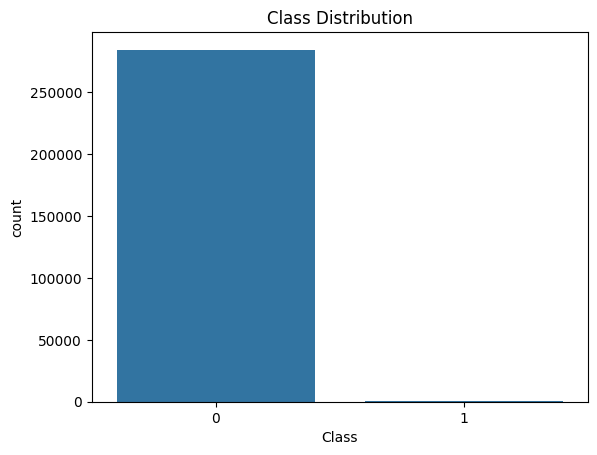

In [10]:
sns.countplot(x="Class", data=creditcard_df)
plt.title("Class Distribution")
plt.show()



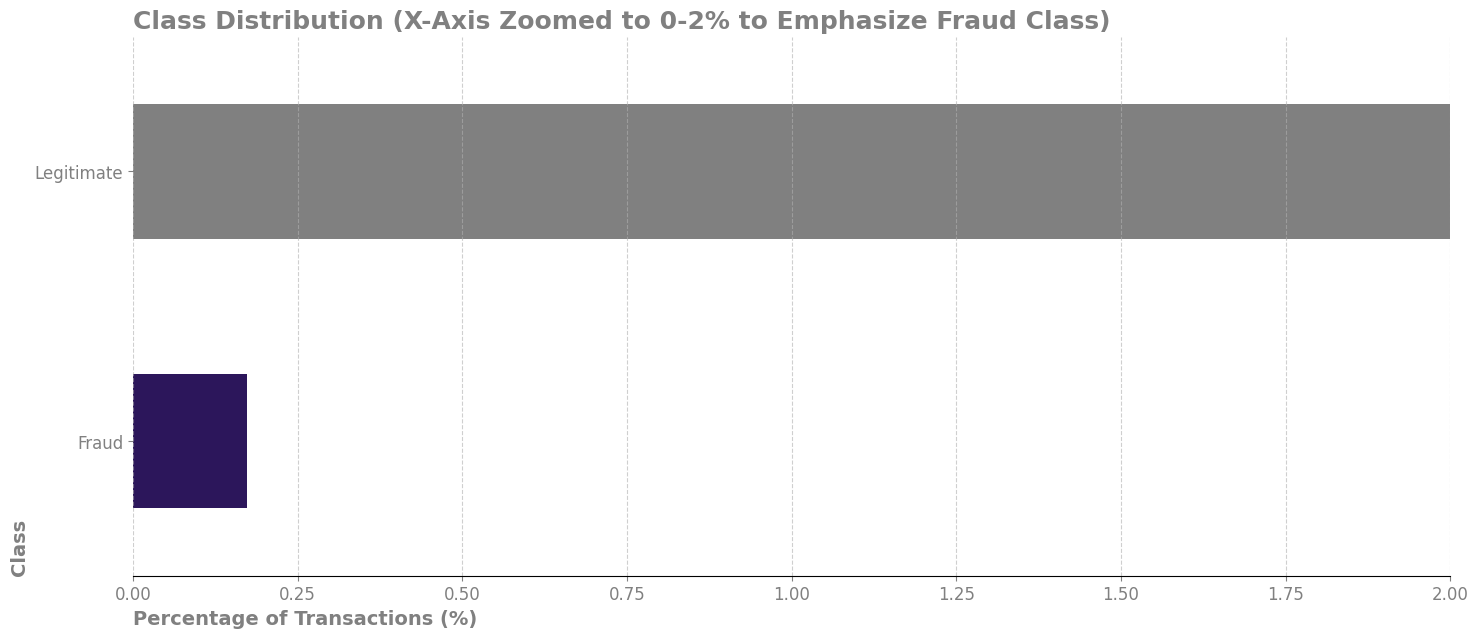

In [11]:
fig, ax = plt.subplots(figsize = (17,7))
sns.barplot(data=class_imbalance,
            x = "proportion",
            y = "Class",
            palette= list(class_imbalance["color"]),
            hue="Class",
            width=0.5,
            ax=ax)
ax.set_xlim(0, 2)
ax.spines[["right", "left", "top"]].set_visible(False)

ax.set_title(
    "Class Distribution (X-Axis Zoomed to 0-2% to Emphasize Fraud Class)",
    fontsize=18,
    fontweight="bold",
    color="gray",
    loc="left"
)

# Axis labels
ax.set_xlabel(
    "Percentage of Transactions (%)",
    fontsize=14,
    fontweight="bold",
    color="gray",
    loc="left"
)

ax.set_ylabel(
    "Class",
    fontsize=14,
    fontweight="bold",
    color="gray",
    loc="bottom"
)

ax.tick_params(axis="x", colors="gray", labelsize=12)
ax.tick_params(axis="y", colors="gray", labelsize=12)

ax.grid(axis="x", linestyle="dashed", alpha=0.6)
plt.savefig("../reports/figures/EDA_class_distribution.png", dpi = 300)

### Feature Distribution by Transaction Class

The KDE plots compare the distributions of each feature (V1–V28) between legitimate and fraudulent transactions. Features with well-separated distributions are more effective at distinguishing fraud, whereas overlapping distributions indicate lower individual discriminative power.

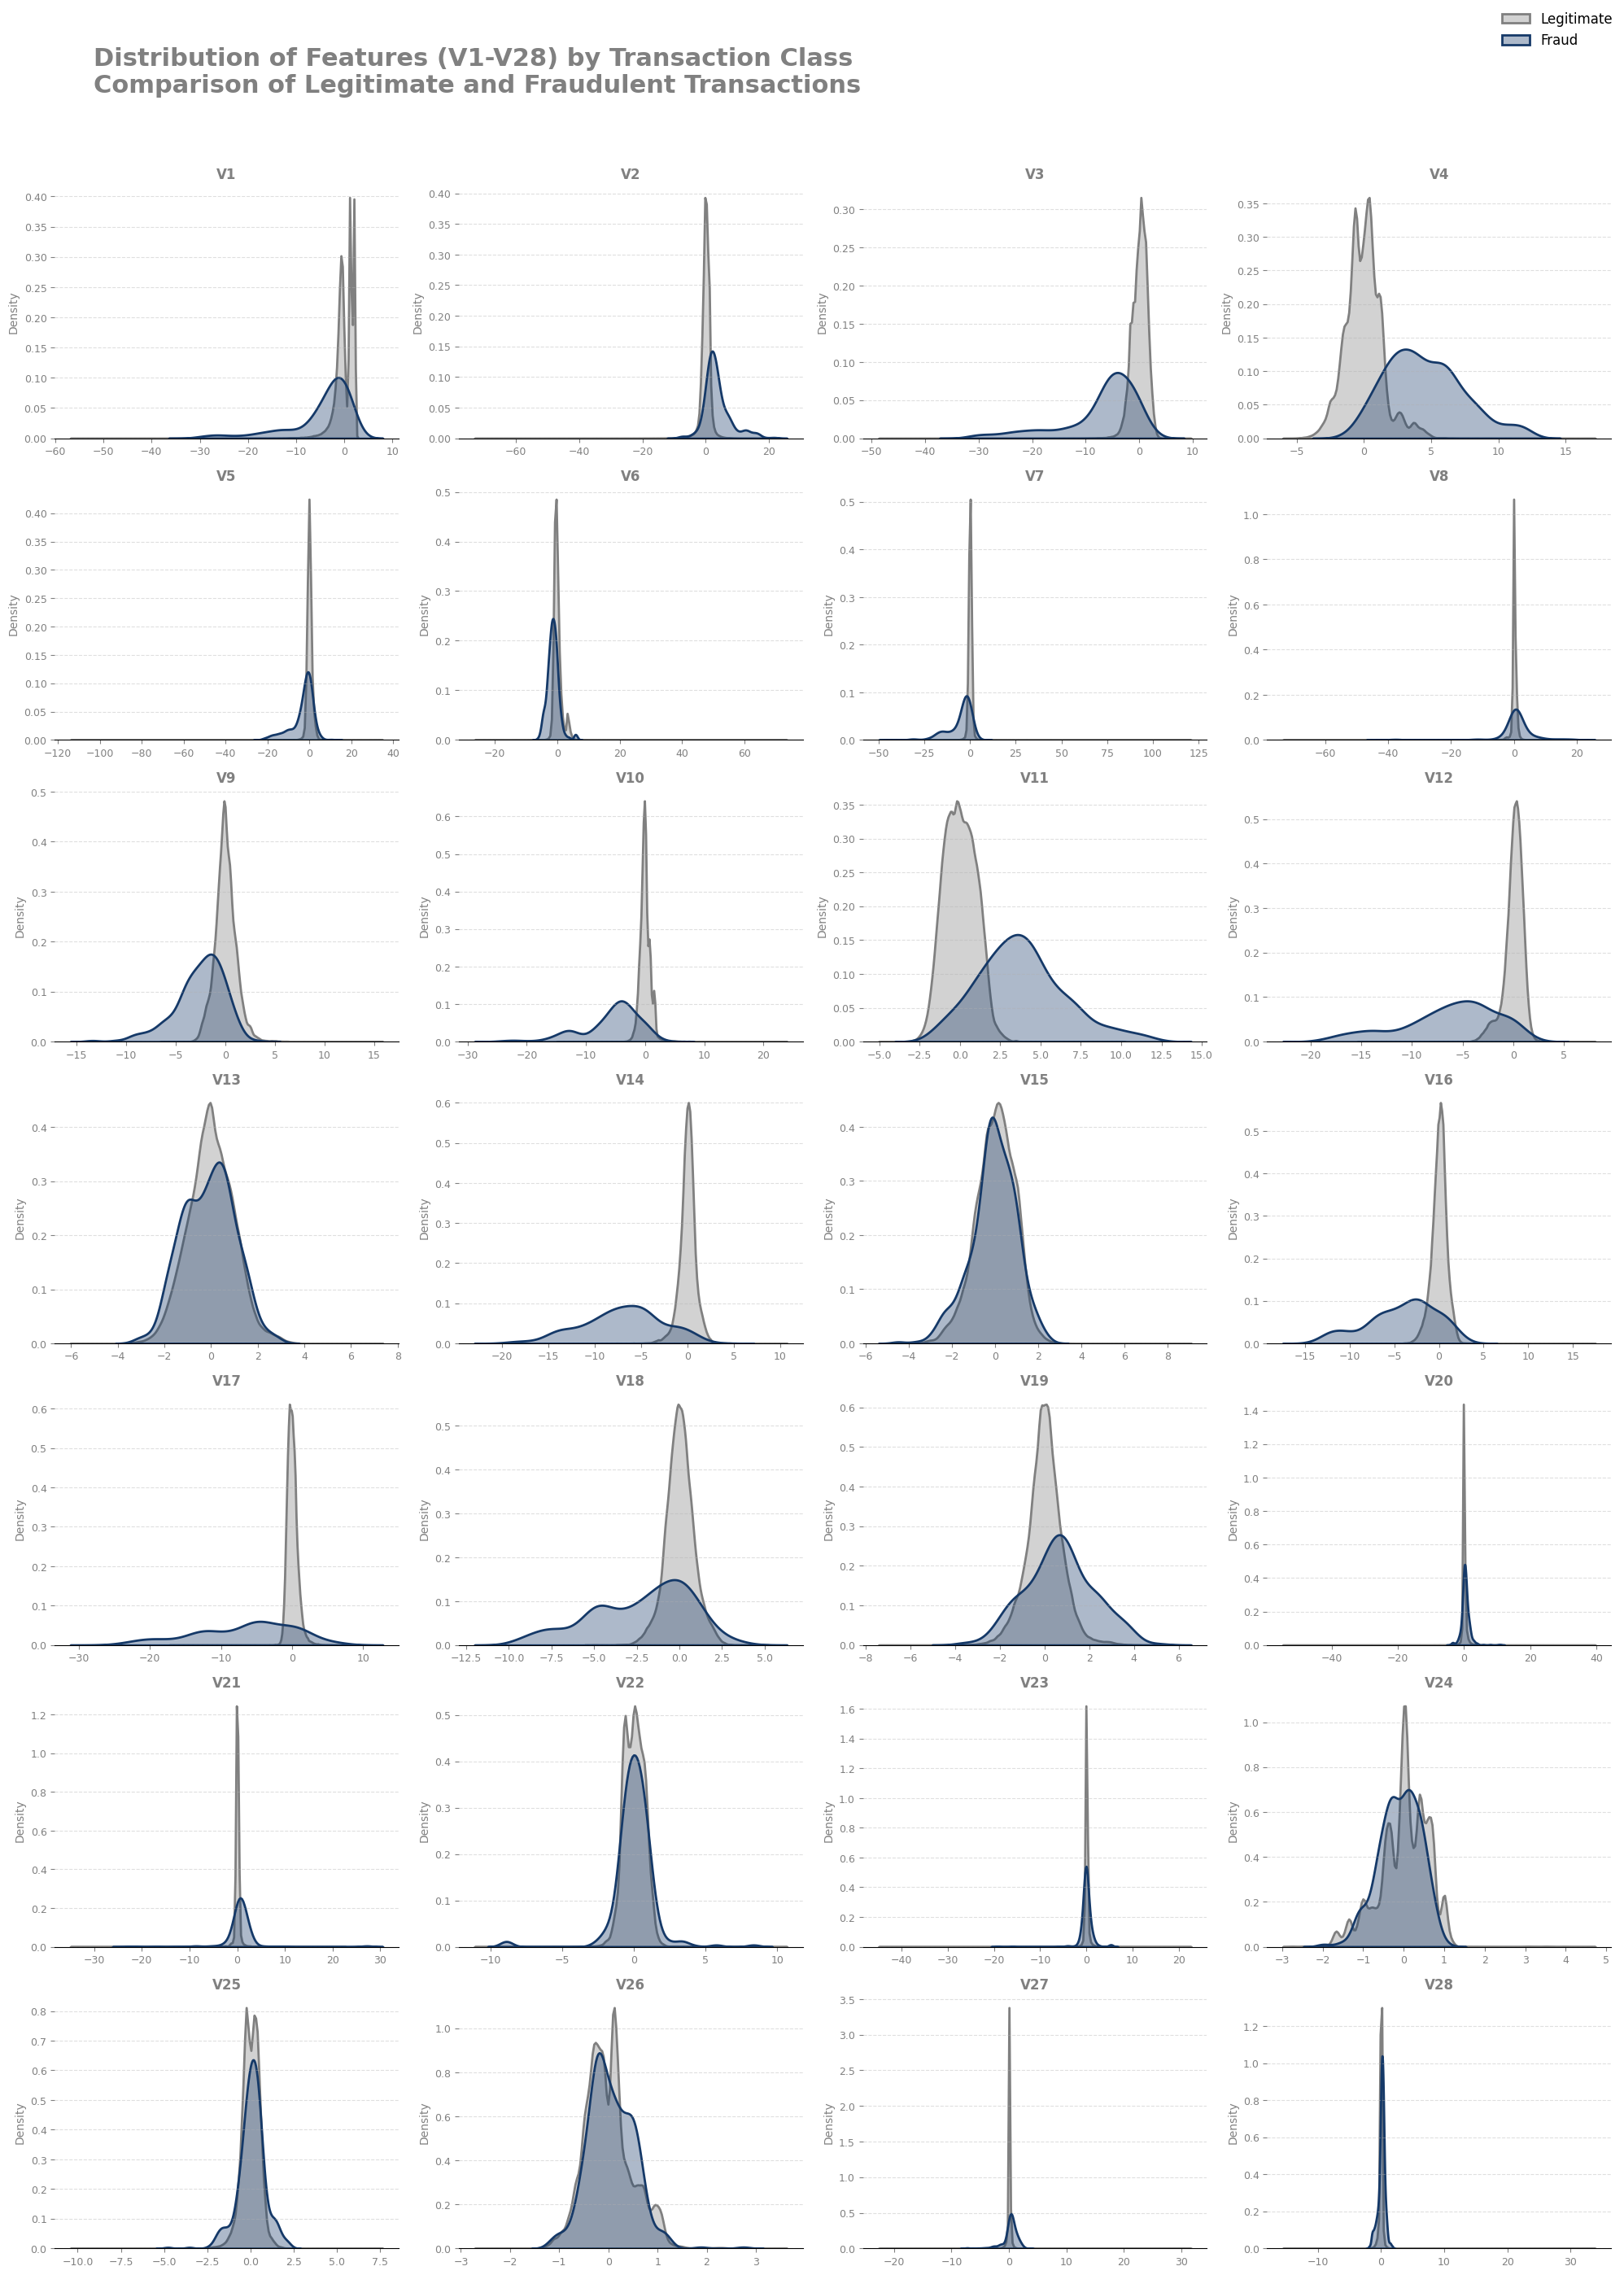

In [12]:
features = [f"V{i}" for i in range(1, 29)]

fig, axes = plt.subplots(7, 4, figsize=(20, 28))
axes = axes.flatten()

for i, feature in enumerate(features):

    sns.kdeplot(
        data=creditcard_df[creditcard_df.Class == 0],
        x=feature,
        fill=True,
        alpha=0.35,
        linewidth=2,
        color="#808080",
        label="Legitimate",
        ax=axes[i]
    )

    sns.kdeplot(
        data=creditcard_df[creditcard_df.Class == 1],
        x=feature,
        fill=True,
        alpha=0.35,
        linewidth=2,
        color="#153968",
        label="Fraud",
        ax=axes[i]
    )


    axes[i].set_title(
        feature,
        fontsize=12,
        weight="bold",
        color="gray"
    )


    axes[i].spines[["top", "right", "left"]].set_visible(False)

    # Axis labels
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Density", fontsize=10, color="gray")


    axes[i].tick_params(axis="both",
                        colors="gray",
                        labelsize=9)


    axes[i].grid(axis="y",
                 linestyle="dashed",
                 alpha=0.4)

    # Remove repeated legends
    if i != 0:
        axes[i].legend().remove()


fig.suptitle(
    "Distribution of Features (V1-V28) by Transaction Class\n"
    "Comparison of Legitimate and Fraudulent Transactions",
    fontsize=22,
    fontweight="bold",
    color="gray",
    x=0.06,
    ha="left"
)

# legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    frameon=False,
    fontsize=12
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("../reports/figures/EDA_feature_distribution_by_transaction_class.png", dpi = 300)

### Skewness Analysis

Skewness measures the asymmetry of a feature's distribution. Values close to zero indicate approximately symmetric distributions, whereas larger positive or negative values indicate increasing skewness.

In [13]:
# Calculate skewness
skewness = creditcard_df.drop(columns="Class").skew().sort_values(key=abs, ascending=False).reset_index()


skewness.columns = ["Feature", "Skewness"]

skewness["color"] = np.where(skewness["Skewness"] >= 0, "#153968","#808080")

In [14]:
skewness

,Feature,Skewness,color
0,Amount,16.977724,#153968
1,V28,11.192091,#153968
2,V8,-8.521944,#808080
3,V23,-5.875140,#808080
4,V2,-4.624866,#808080
5,V17,-3.844914,#808080
6,V21,3.592991,#153968
7,V1,-3.280667,#808080
8,V7,2.553907,#153968
9,V5,-2.425901,#808080


The analysis shows that most PCA-transformed features (V1–V28) exhibit relatively low skewness, suggesting that the PCA transformation has produced approximately symmetric distributions. In contrast, the Amount feature is typically positively skewed due to the presence of a small number of high-value transactions.

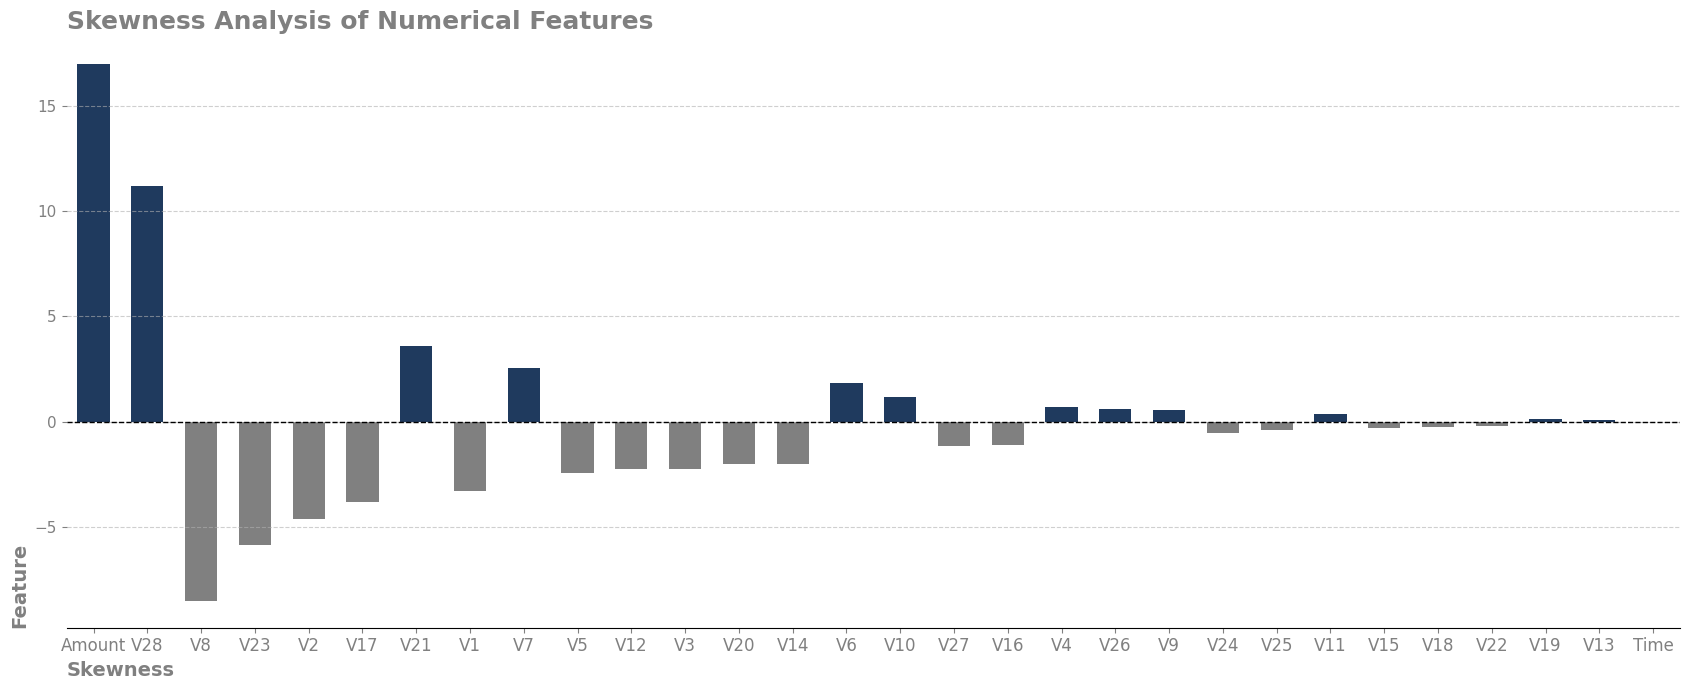

In [15]:
fig, ax = plt.subplots(figsize=(17, 7))

sns.barplot(
    data=skewness,
    x= "Feature", 
    y= "Skewness",
    palette=list(skewness["color"]),
    hue="Feature",
    dodge=False,
    width=0.6,
    legend=False,
    ax=ax
)

ax.spines[["right", "left", "top"]].set_visible(False)


ax.set_title(
    "Skewness Analysis of Numerical Features",
    fontsize=18,
    fontweight="bold",
    color="gray",
    loc="left"
)

ax.set_xlabel(
    "Skewness",
    fontsize=14,
    fontweight="bold",
    color="gray",
    loc="left"
)

ax.set_ylabel(
    "Feature",
    fontsize=14,
    fontweight="bold",
    color="gray",
    loc="bottom"
)

ax.tick_params(axis="x", colors="gray", labelsize=12)
ax.tick_params(axis="y", colors="gray", labelsize=11)

ax.grid(axis="y", linestyle="dashed", alpha=0.6)

# Reference line at zero
ax.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.tight_layout()

plt.savefig("../reports/figures/EDA_skewness_analysis.png",dpi=300)

plt.show()

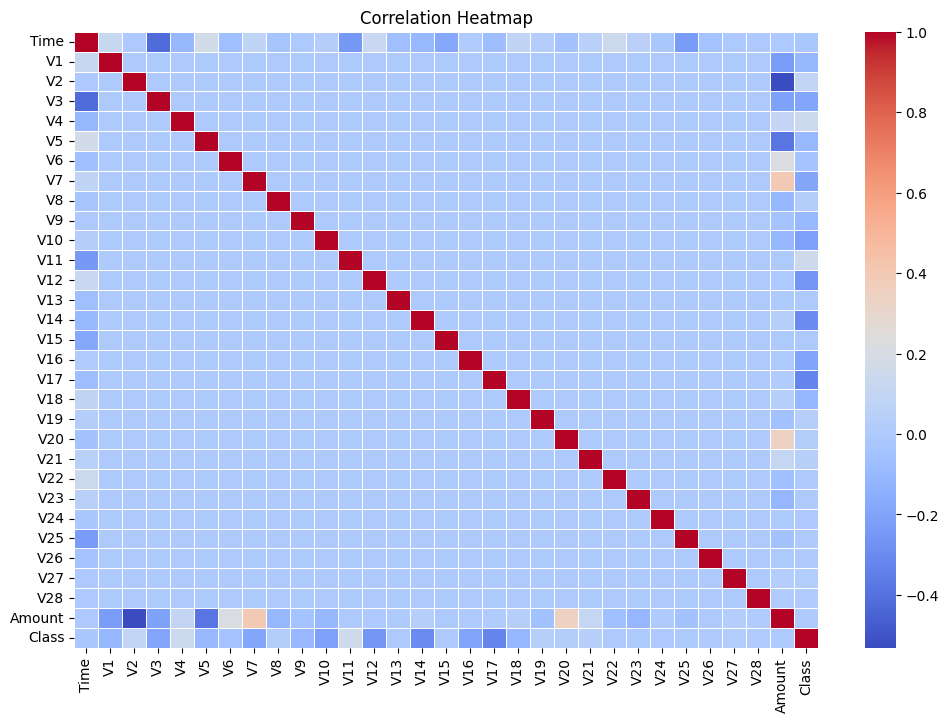

In [16]:
plt.figure(figsize=(12, 8))
sns.heatmap(creditcard_df.corr(), cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


## preprossing

I will first test 3 popular scaling methods and create a histogram chart for each to see which method works best.

In [17]:
from sklearn.preprocessing import (
    MinMaxScaler, StandardScaler, RobustScaler
)
from sklearn.model_selection import train_test_split

In [18]:
from math import ceil

In [19]:
df2 = creditcard_df.copy(deep=True)

In [20]:
df2.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [21]:
df2.shape

(284807, 31)

In [22]:
x = df2.drop(columns=["Class"])
y = df2["Class"].values.reshape(-1, 1)

In [23]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [24]:
scaler = MinMaxScaler(feature_range=(0, 1))

In [25]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

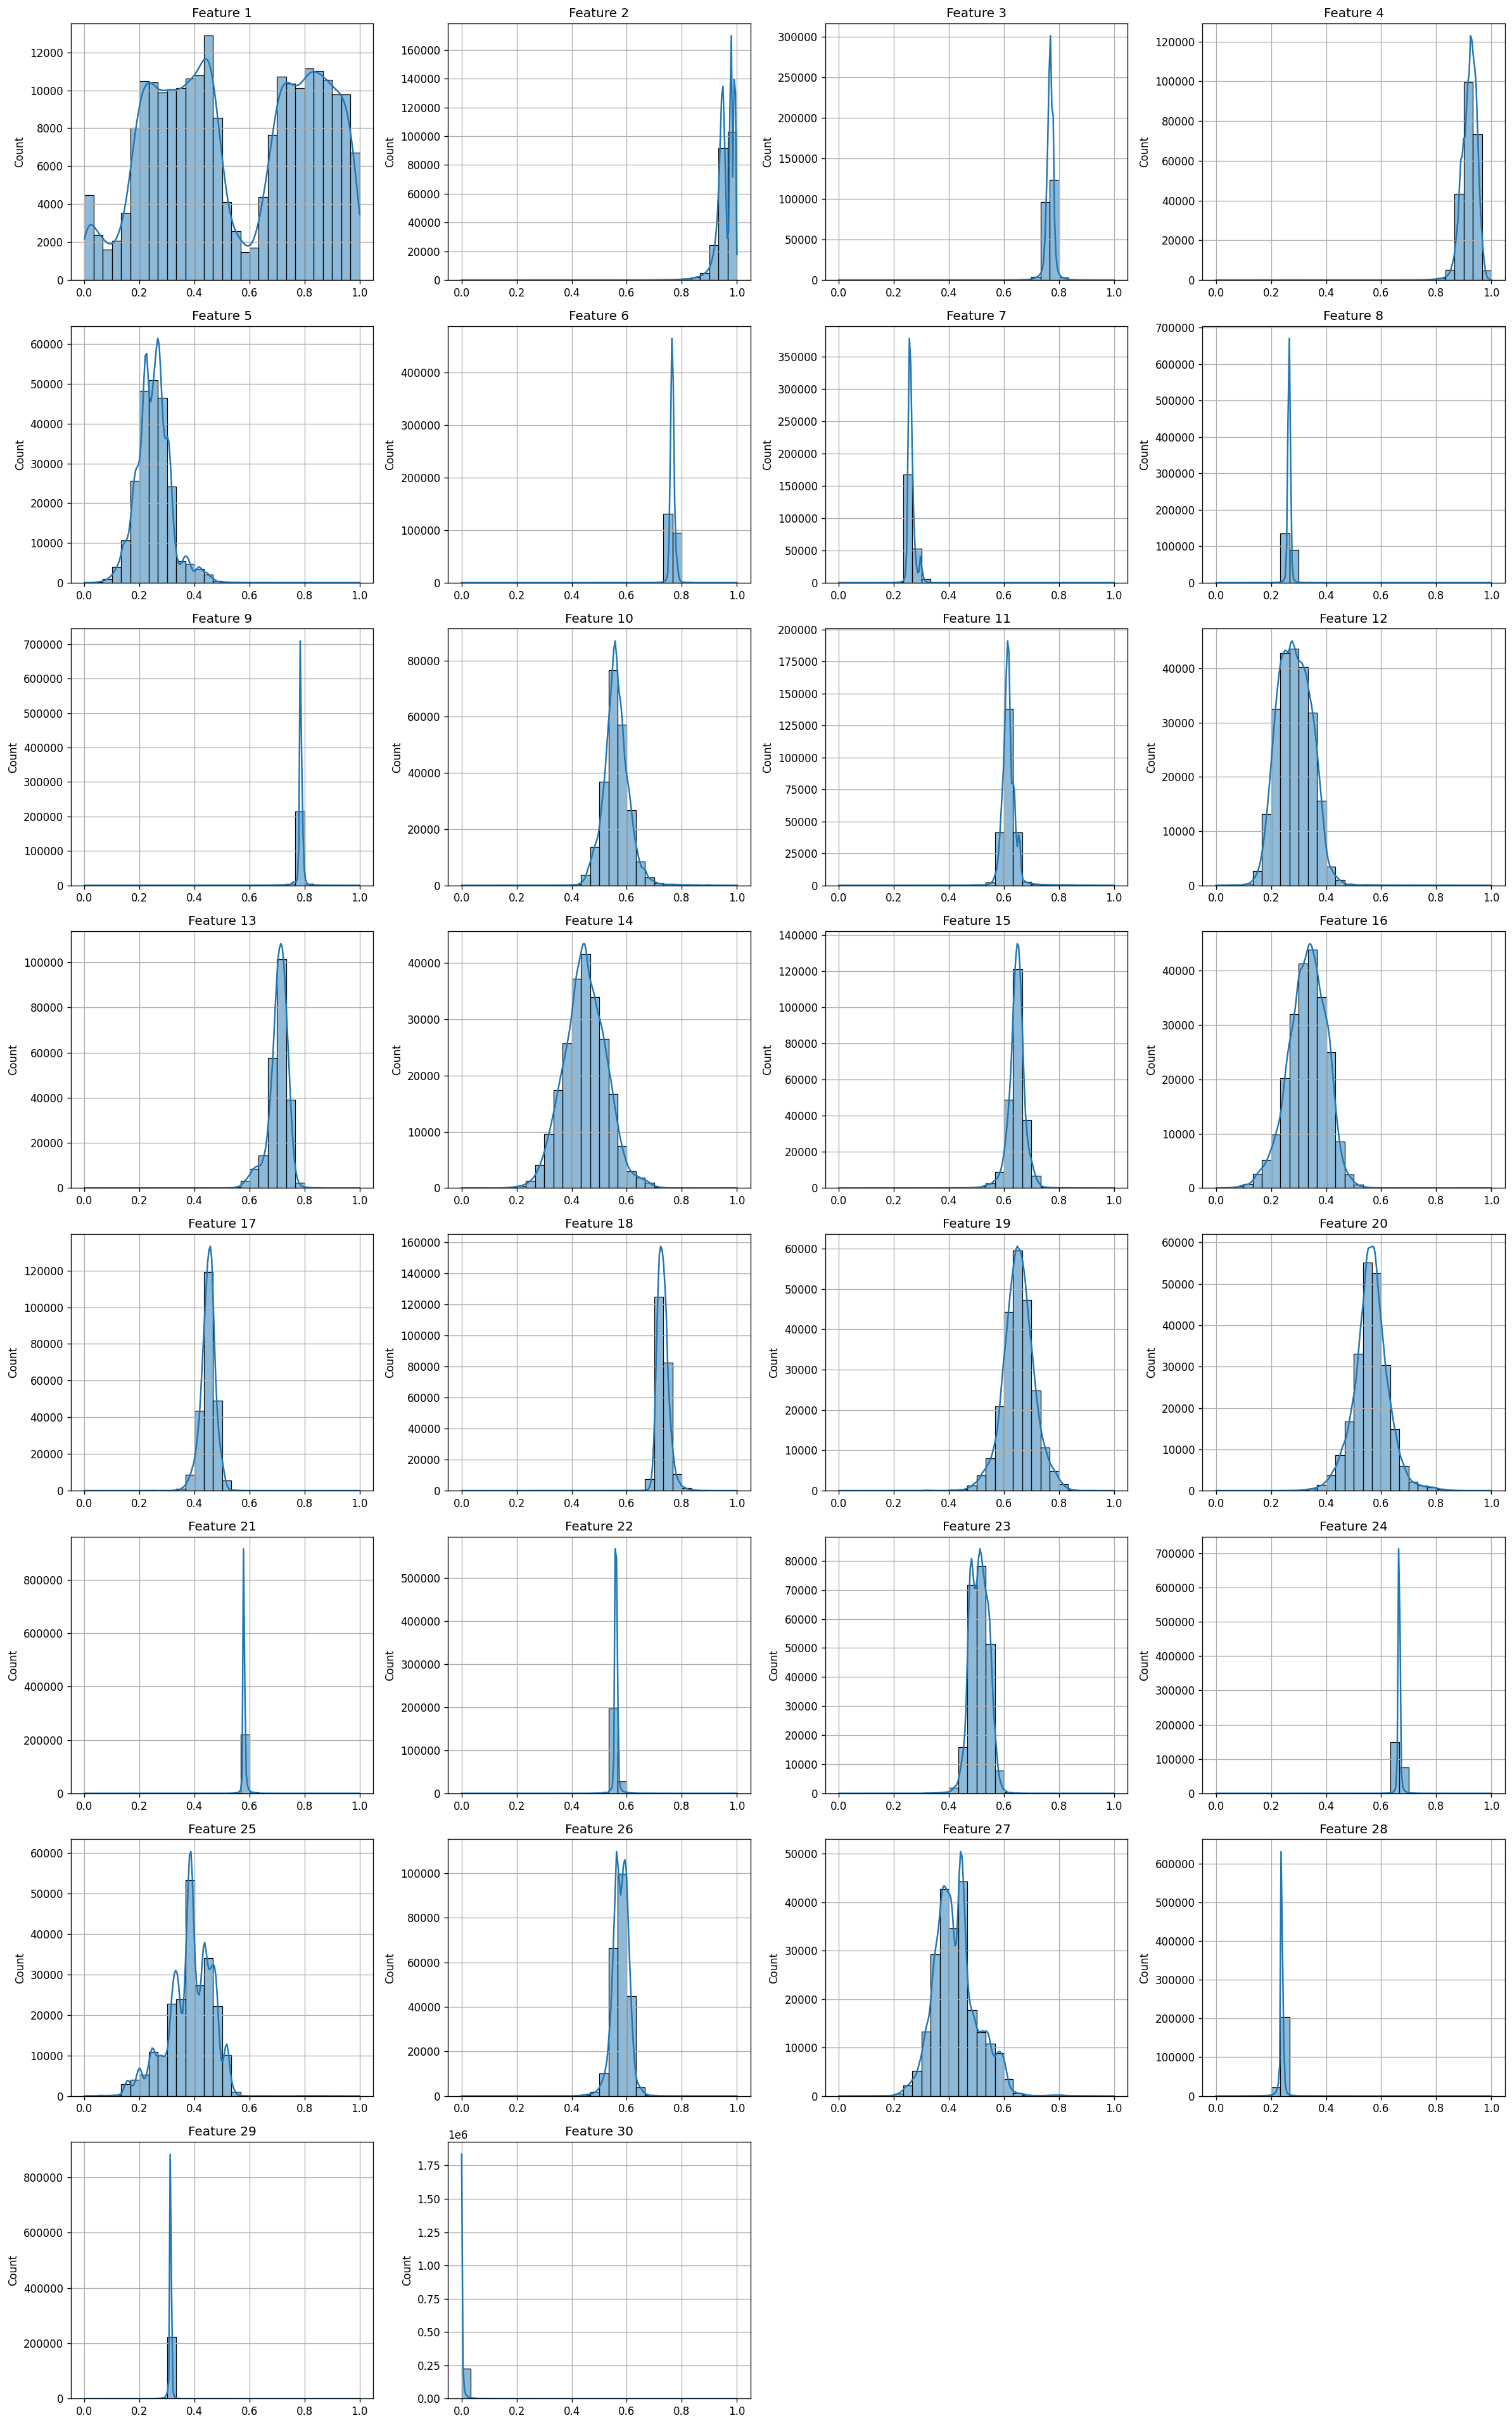

In [26]:
n_features = x_train_scaled.shape[1]

n_cols = 4
n_rows = ceil(n_features / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, 4 * n_rows),
    dpi=120
)

axes = axes.flatten()

for i in range(n_features):
    sns.histplot(
        x=x_train_scaled[:, i],
        bins=30,
        kde=True,
        fill=True,
        ax=axes[i]
    )

    axes[i].set_title(f"Feature {i+1}", fontsize=12)
    axes[i].grid(True)


for i in range(n_features, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [27]:
scaler2 = StandardScaler()

In [28]:
x_train_scaled2 = scaler2.fit_transform(x_train)
x_test_scaled2 = scaler2.transform(x_test)

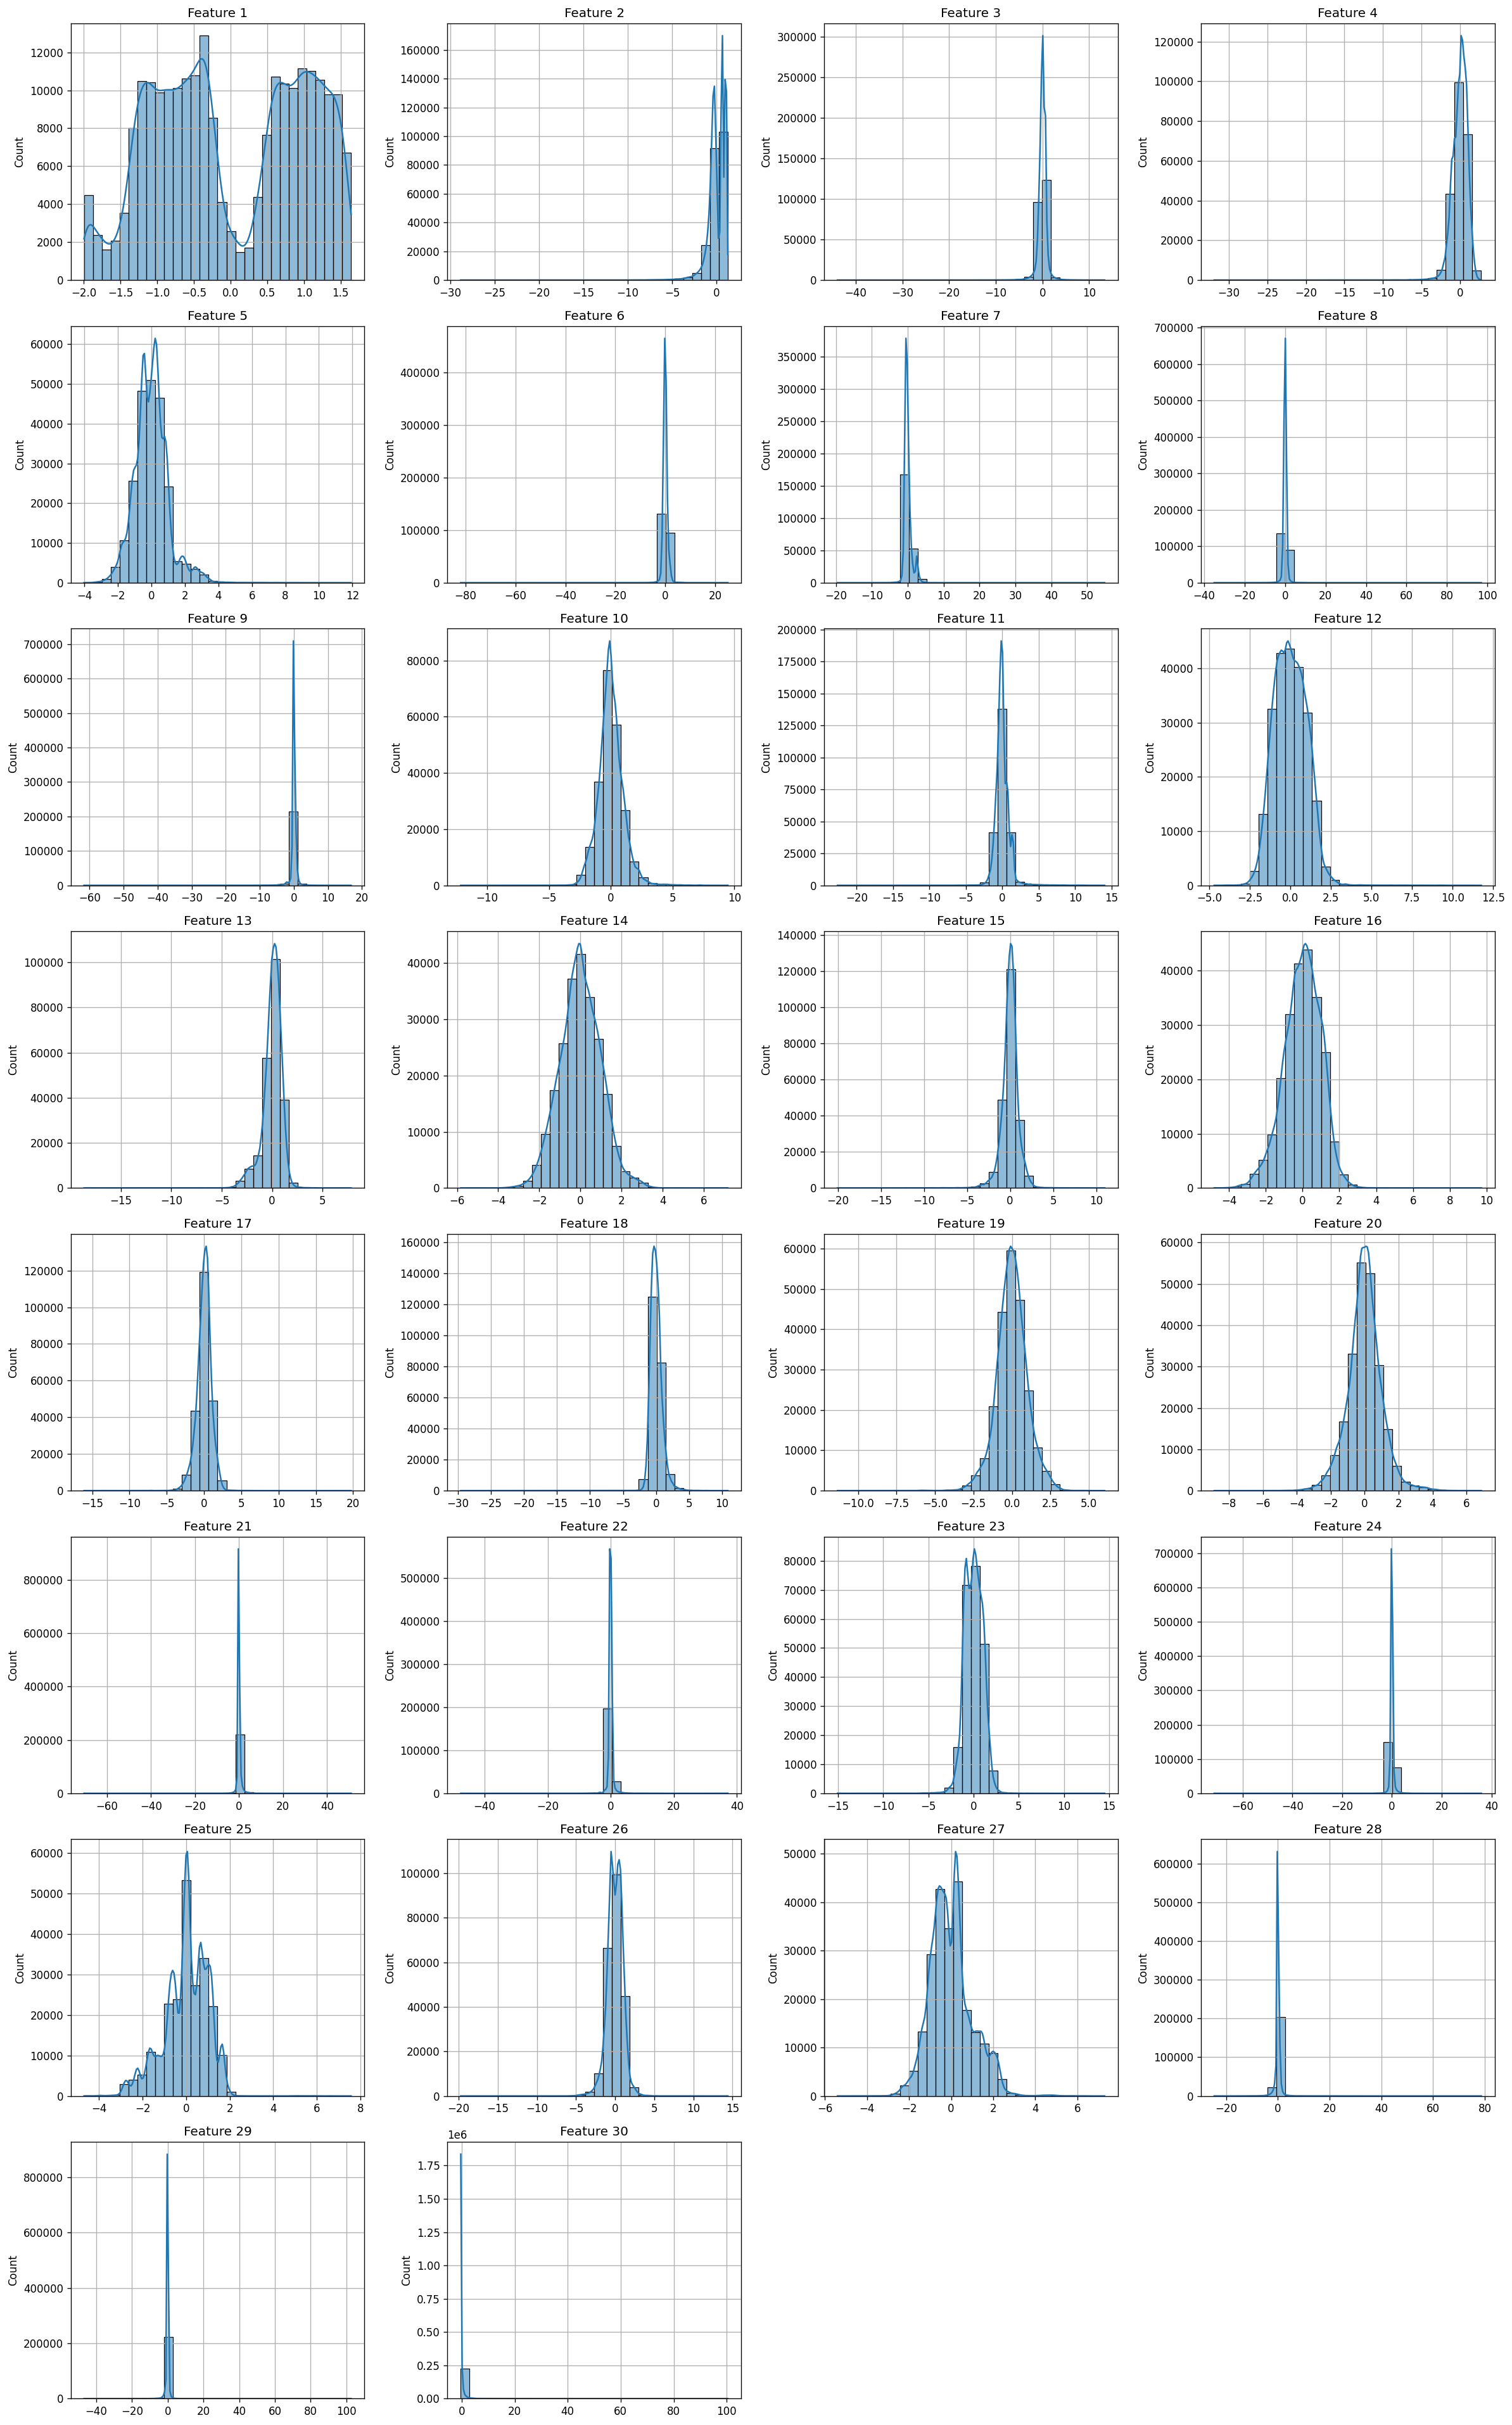

In [29]:
n_features = x_train_scaled2.shape[1]

n_cols = 4
n_rows = ceil(n_features / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, 4 * n_rows),
    dpi=120
)

axes = axes.flatten()

for i in range(n_features):
    sns.histplot(
        x=x_train_scaled2[:, i],
        bins=30,
        kde=True,
        fill=True,
        ax=axes[i]
    )

    axes[i].set_title(f"Feature {i+1}", fontsize=12)
    axes[i].grid(True)


for i in range(n_features, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [30]:
scaler3 = RobustScaler()
x_train_scaled3 = scaler3.fit_transform(x_train)
x_test_scaled3 = scaler3.transform(x_test)

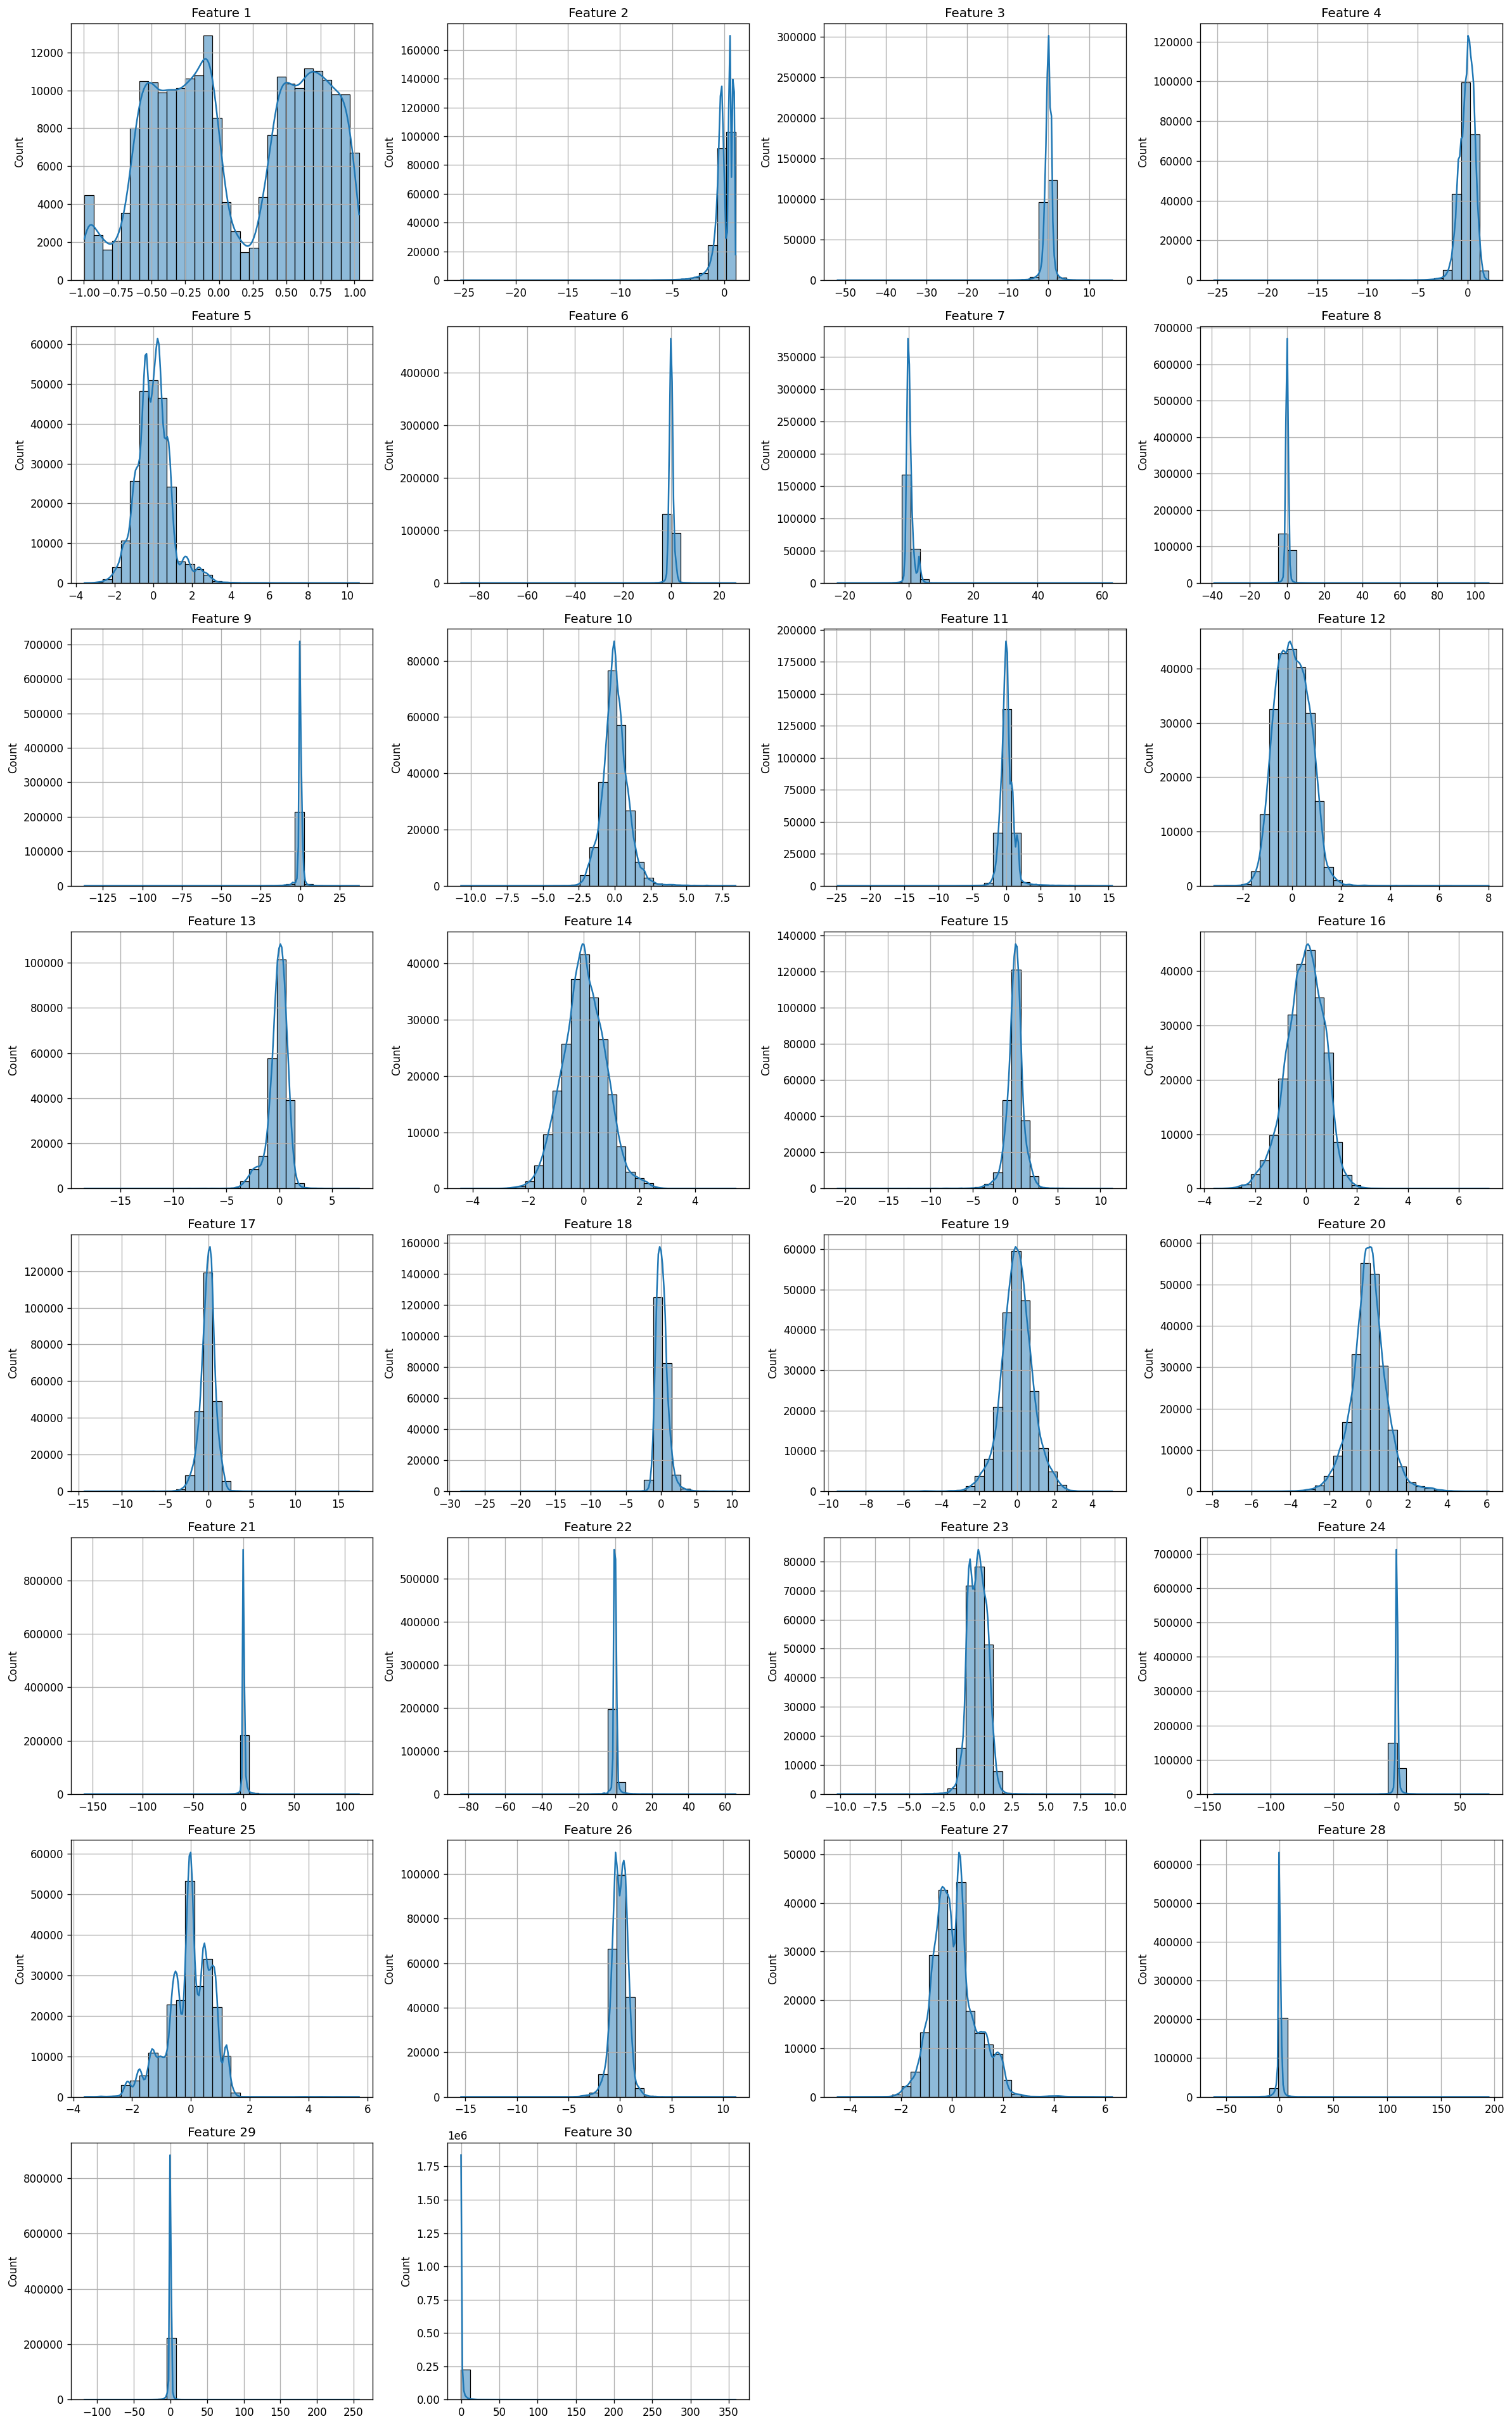

In [31]:
n_features = x_train_scaled3.shape[1]

n_cols = 4
n_rows = ceil(n_features / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, 4 * n_rows),
    dpi=120
)

axes = axes.flatten()

for i in range(n_features):
    sns.histplot(
        x=x_train_scaled3[:, i],
        bins=30,
        kde=True,
        fill=True,
        ax=axes[i]
    )

    axes[i].set_title(f"Feature {i+1}", fontsize=12)
    axes[i].grid(True)


for i in range(n_features, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [32]:
from sklearn.compose import ColumnTransformer

In [33]:
del scaler, scaler2, scaler3, x_train_scaled, x_train_scaled2, x_train_scaled3

In [34]:
del x_test_scaled, x_test_scaled2, x_test_scaled3

In [35]:
scaler_transformer = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), x.columns.tolist())
    ],
    remainder="drop"
)

Okay, now let's move on to the popular methods for selecting features.

First, we use correlation.

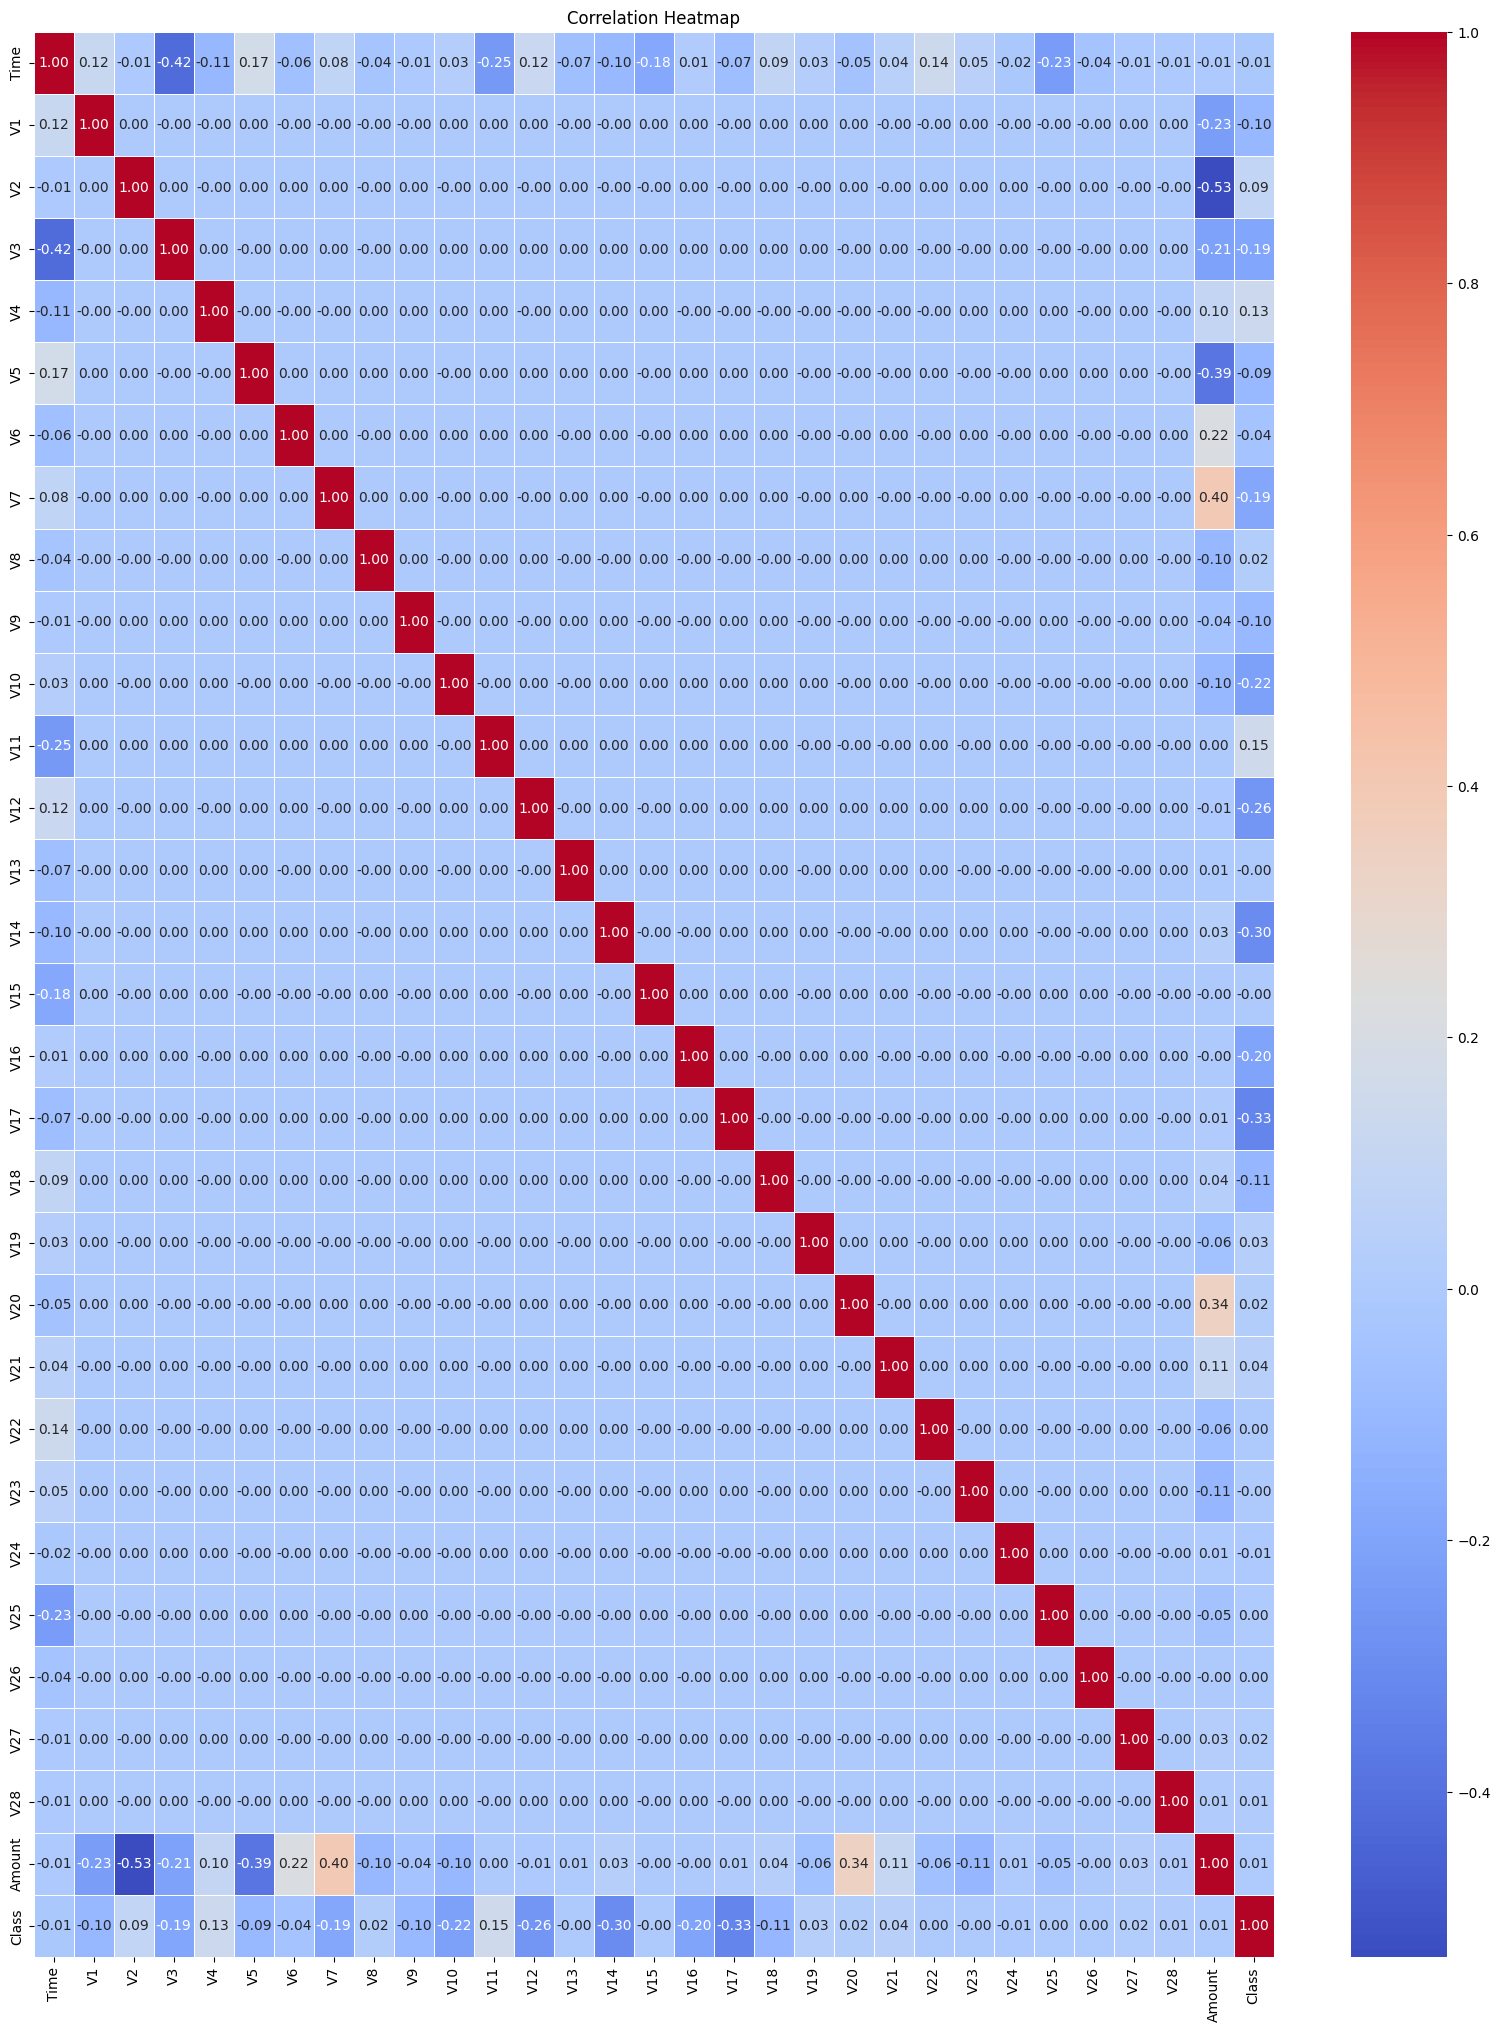

In [36]:
plt.figure(figsize=(20, 25))
sns.heatmap(df2.corr(), cmap="coolwarm", linewidths=0.5, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


In [37]:
df2["Amount"].corr(other=df2["Class"])

np.float64(0.005631753006768529)

In [38]:
corr_df = pd.DataFrame(
    data={
        "columns":df2.columns.to_list(),
        "corr with target":[
            df2[col].corr(other=df2["Class"])
            for col in df2.columns
        ]
    }
).sort_values(by="corr with target", ascending=False).drop(index=30)

In [39]:
top_3_corr_pos = corr_df[corr_df["corr with target"] >= 0.09]

In [40]:
top_3_corr_pos

,columns,corr with target
11,V11,0.154876
4,V4,0.133447
2,V2,0.091289


In [41]:
top_3_corr_neg = corr_df[corr_df["corr with target"] < -0.20]

In [42]:
top_3_corr_neg

,columns,corr with target
10,V10,-0.216883
12,V12,-0.260593
14,V14,-0.302544
17,V17,-0.326481


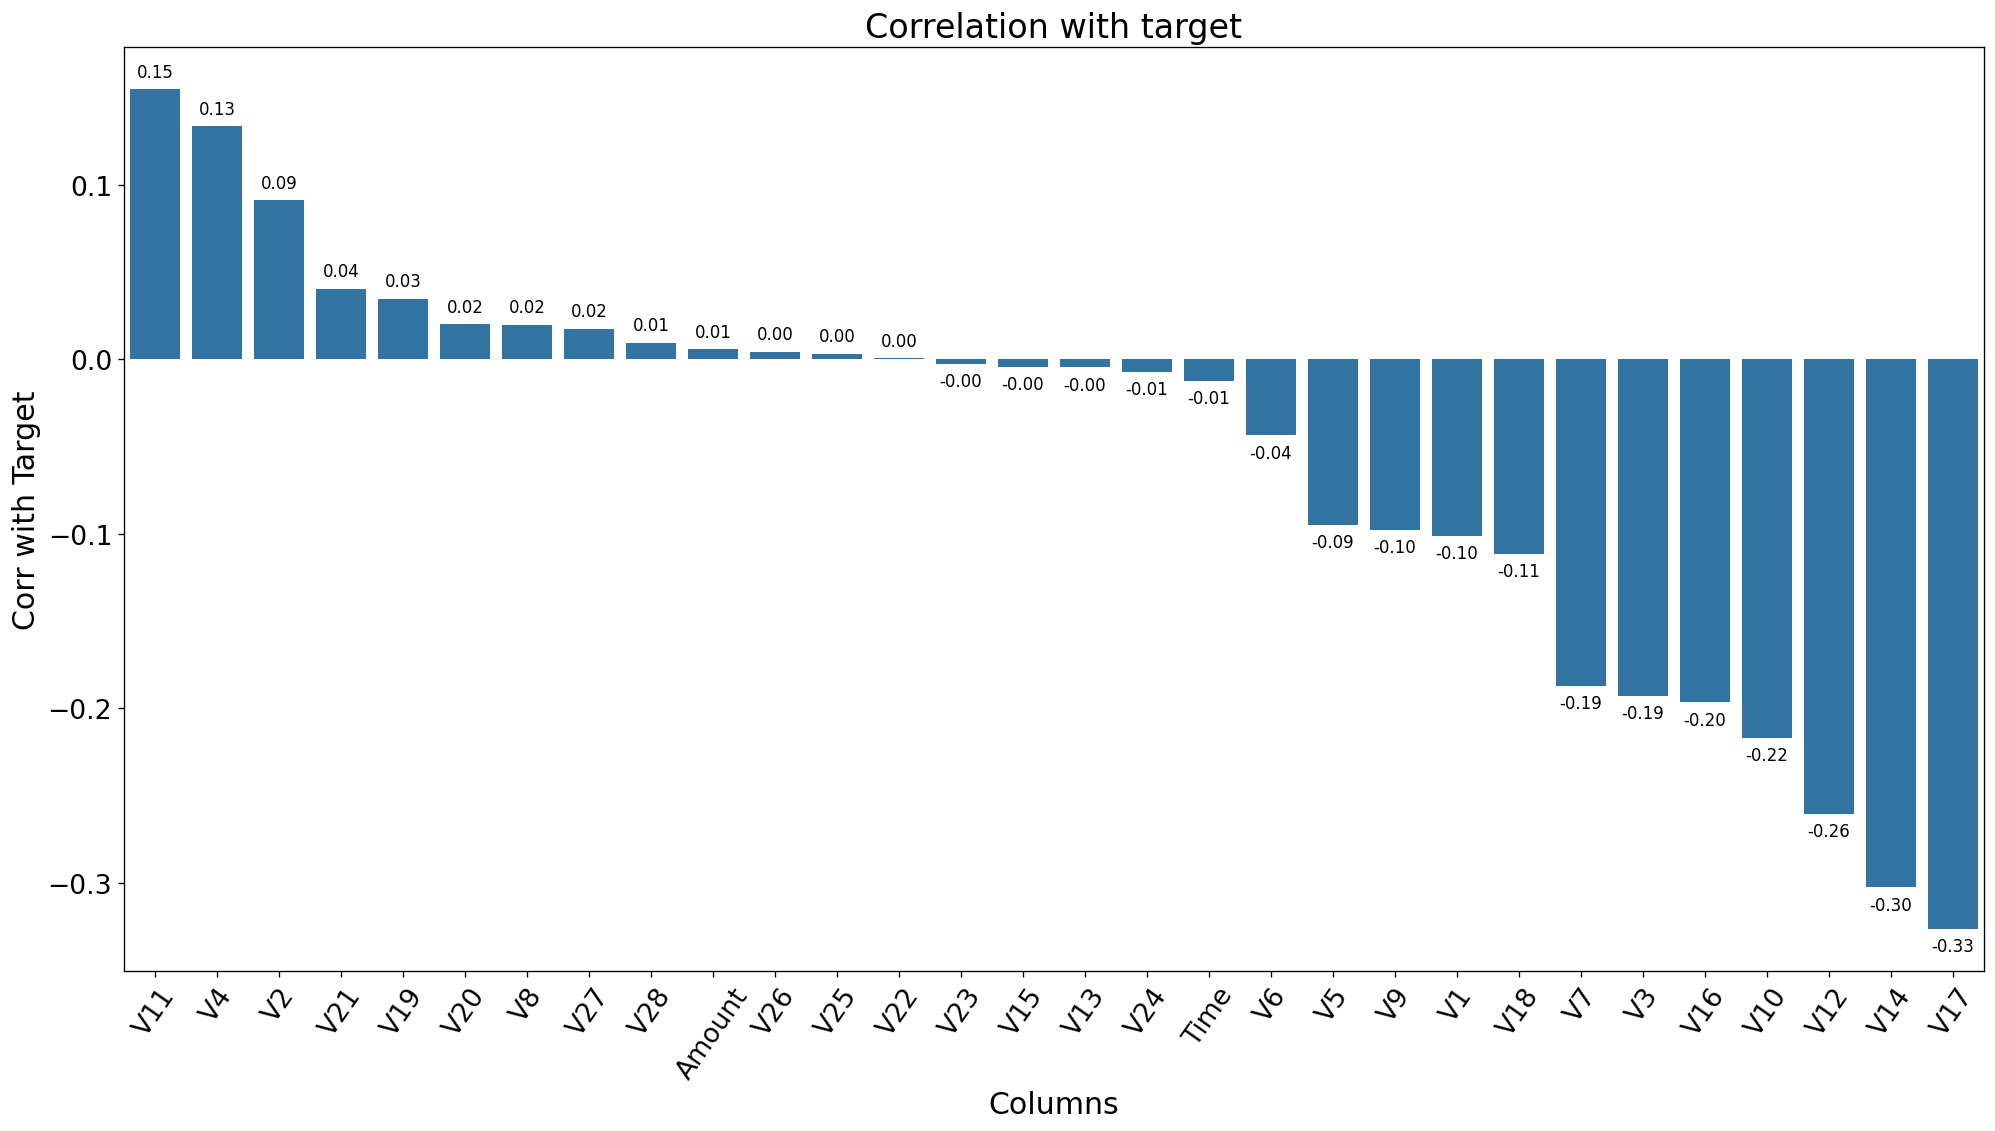

In [43]:
fig, ax = plt.subplots(figsize=(20, 10), dpi=120)

sns.barplot(
    data=corr_df,
    x="columns",
    y="corr with target",
    ax=ax
)

ax.bar_label(
    ax.containers[0],
    fmt="%.2f",
    fontsize=10,
    padding=5
)

ax.set_title("Correlation with target", fontsize=20)
ax.set_xlabel("Columns", fontsize=18)
ax.set_ylabel("Corr with Target", fontsize=18)
ax.tick_params(axis="both", labelsize=16)
plt.xticks(rotation=55)
plt.savefig("../reports/figures/Correlation_with_target.jpg")
plt.show()

📌 The Pearson correlation coefficient between the features and the target variable showed that no feature had a strong linear correlation with Target. The highest positive correlation was for V11 (≈0.15) and the highest negative correlation was for V17 (≈−0.33). 

📌 These results indicate that the prediction of the target class is likely to depend on the combination of several features and that the use of multivariate and nonlinear models can perform better than single-feature analysis. 

📌 Also, the Time feature and a number of components have close to zero correlations, but this does not necessarily mean that they are insignificant, as nonlinear relationships or interactions between features may be revealed in more complex models.

Let's move on to the statistical method `mutual_info_classif`

In [44]:
from sklearn.feature_selection import mutual_info_classif

In [45]:
mi = mutual_info_classif(
    x,
    y.ravel(), 
    random_state=42
)

In [46]:
mi_df = pd.DataFrame({
    "Feature": df2.drop(columns=["Class"]).columns.to_list(),
    "Mutual Information": mi
})

mi_df = mi_df.sort_values(
    by="Mutual Information",
    ascending=False
).reset_index(drop=True)

mi_df

,Feature,Mutual Information
0,V17,0.008258
1,V14,0.008136
2,V12,0.007601
3,V10,0.007530
4,V11,0.006831
5,V16,0.006144
6,V4,0.004976
7,V3,0.004952
8,V18,0.004317
9,V9,0.004277


In [47]:
top_5 = mi_df[mi_df["Mutual Information"]> 0.005]["Feature"].unique().tolist()

In [48]:
print(top_5)

['V17', 'V14', 'V12', 'V10', 'V11', 'V16']


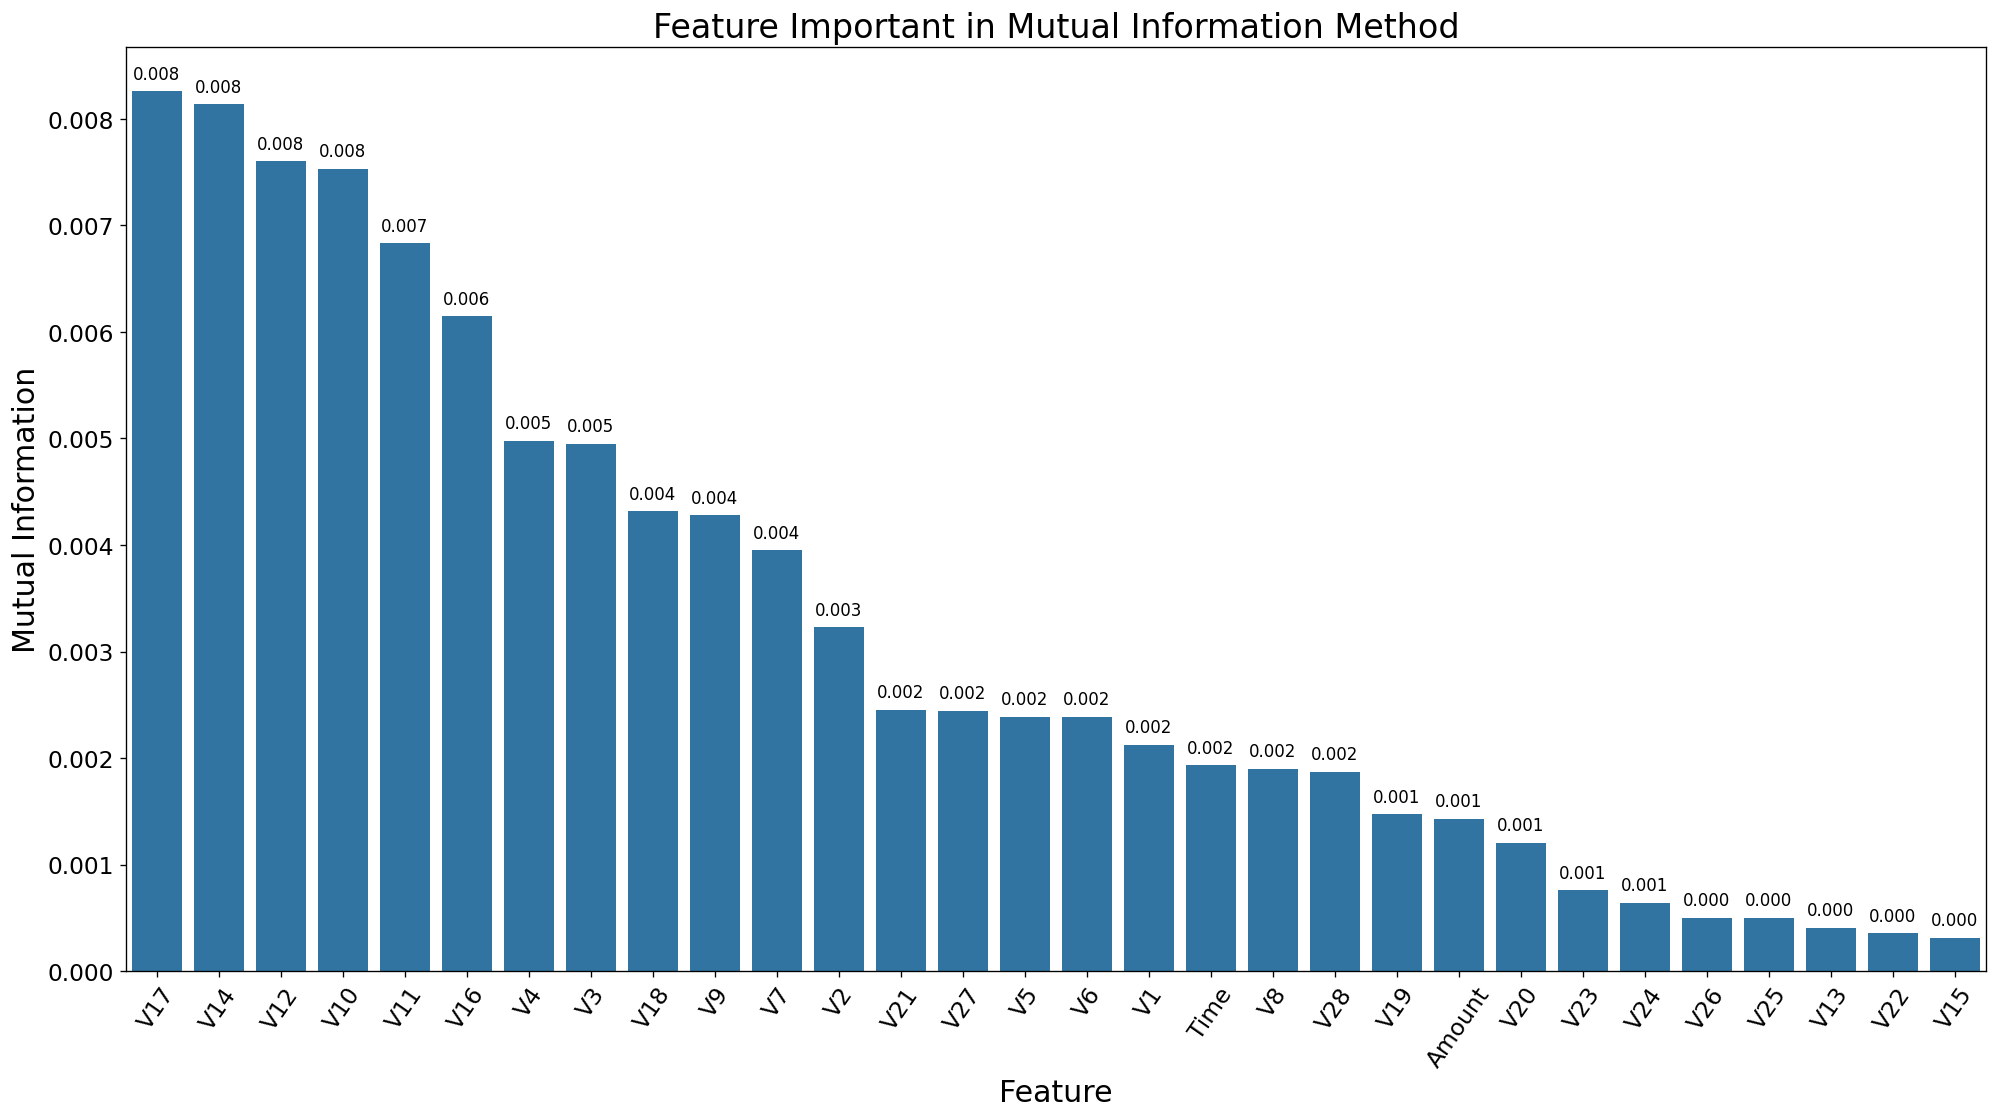

In [49]:
fig, ax = plt.subplots(figsize=(20, 10), dpi=120)

sns.barplot(
    data=mi_df,
    x="Feature",
    y="Mutual Information",
    ax=ax
)

ax.bar_label(
    ax.containers[0],
    fmt="%.3f",
    fontsize=10,
    padding=5
)
plt.title("Feature Important in Mutual Information Method", fontsize=20)
plt.xlabel("Feature", fontsize=18)
plt.ylabel("Mutual Information", fontsize=18)
plt.tick_params(axis="both", labelsize=14)
plt.xticks(rotation=55)
plt.savefig("../reports/figures/Mutual_Information.jpg")
plt.show()

| Feature | Correlation | Mutual Information | Interpretation |
|---------|:-----------:|:------------------:|----------------|
| **V17** | ⭐⭐⭐ | ⭐⭐⭐ | ✅ Highly important in both methods |
| **V14** | ⭐⭐⭐ | ⭐⭐⭐ | ✅ Highly important in both methods |
| **V12** | ⭐⭐⭐ | ⭐⭐⭐ | ✅ Highly important in both methods |
| **V10** | ⭐⭐⭐ | ⭐⭐⭐ | ✅ Highly important in both methods |
| **V16** | ⭐⭐⭐ | ⭐⭐⭐ | ✅ Highly important in both methods |
| **V11** | ⭐⭐⭐ | ⭐⭐⭐ | ✅ Highly important in both methods |
| **V3**  | ⭐⭐ | ⭐⭐ | ✅ Important in both methods |
| **V7**  | ⭐⭐ | ⭐⭐ | ✅ Important in both methods |
| **V4**  | ⭐⭐ | ⭐⭐ | ✅ Important in both methods |
| **V2**  | ⭐⭐ | ⭐⭐ | ✅ Important in both methods |
| **V18** | ⭐⭐ | ⭐⭐ | ✅ Important in both methods |
| **V9**  | ⭐ | ⭐⭐ | 🔶 More important according to Mutual Information |
| **V6**  | ⭐ | ⭐⭐ | 🔶 More important according to Mutual Information |
| **V5**  | ⭐ | ⭐⭐ | 🔶 More important according to Mutual Information |
| **V21** | ⭐ | ⭐⭐ | 🔶 More important according to Mutual Information |
| **V27** | ⭐ | ⭐⭐ | 🔶 More important according to Mutual Information |
| **V19** | ⭐⭐ | ⭐ | 🔷 More important according to Correlation |
| **V20** | ⭐⭐ | ⭐ | 🔷 More important according to Correlation |
| **V28** | ⭐ | ⭐ | 🔷 Slightly more important according to Correlation |
| **Time** | ⭐ | ⭐ | ⚪ Low importance in both methods |
| **Amount** | ⭐ | ⭐ | ⚪ Low importance in both methods |
| **V13** | ⭐ | ⭐ | ⚪ Very low importance in both methods |
| **V15** | ⭐ | ⭐ | ⚪ Very low importance in both methods |
| **V22** | ⭐ | ⭐ | ⚪ Very low importance in both methods |
| **V23** | ⭐ | ⭐ | ⚪ Very low importance in both methods |
| **V24** | ⭐ | ⭐ | ⚪ Very low importance in both methods |
| **V25** | ⭐ | ⭐ | ⚪ Very low importance in both methods |
| **V26** | ⭐ | ⭐ | ⚪ Very low importance in both methods |

## ANOVA

In [50]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

In [51]:
selector = SelectKBest(
    score_func=f_classif,
    k="all"
)

selector.fit(x, y.ravel())

SelectKBest(k='all')

In [52]:
anova_df = pd.DataFrame({
    "Feature": df2.drop(columns=["Class"]).columns,
    "F Score": selector.scores_,
    "P-value": selector.pvalues_
})

anova_df = anova_df.sort_values(
    by="F Score",
    ascending=False
)

anova_df.head(10)

,Feature,F Score,P-value
17,V17,33979.168593,0.0
14,V14,28695.547788,0.0
12,V12,20749.822361,0.0
10,V10,14057.979985,0.0
16,V16,11443.349428,0.0
3,V3,11014.508305,0.0
7,V7,10349.605408,0.0
11,V11,6999.355047,0.0
4,V4,5163.832114,0.0
18,V18,3584.380605,0.0


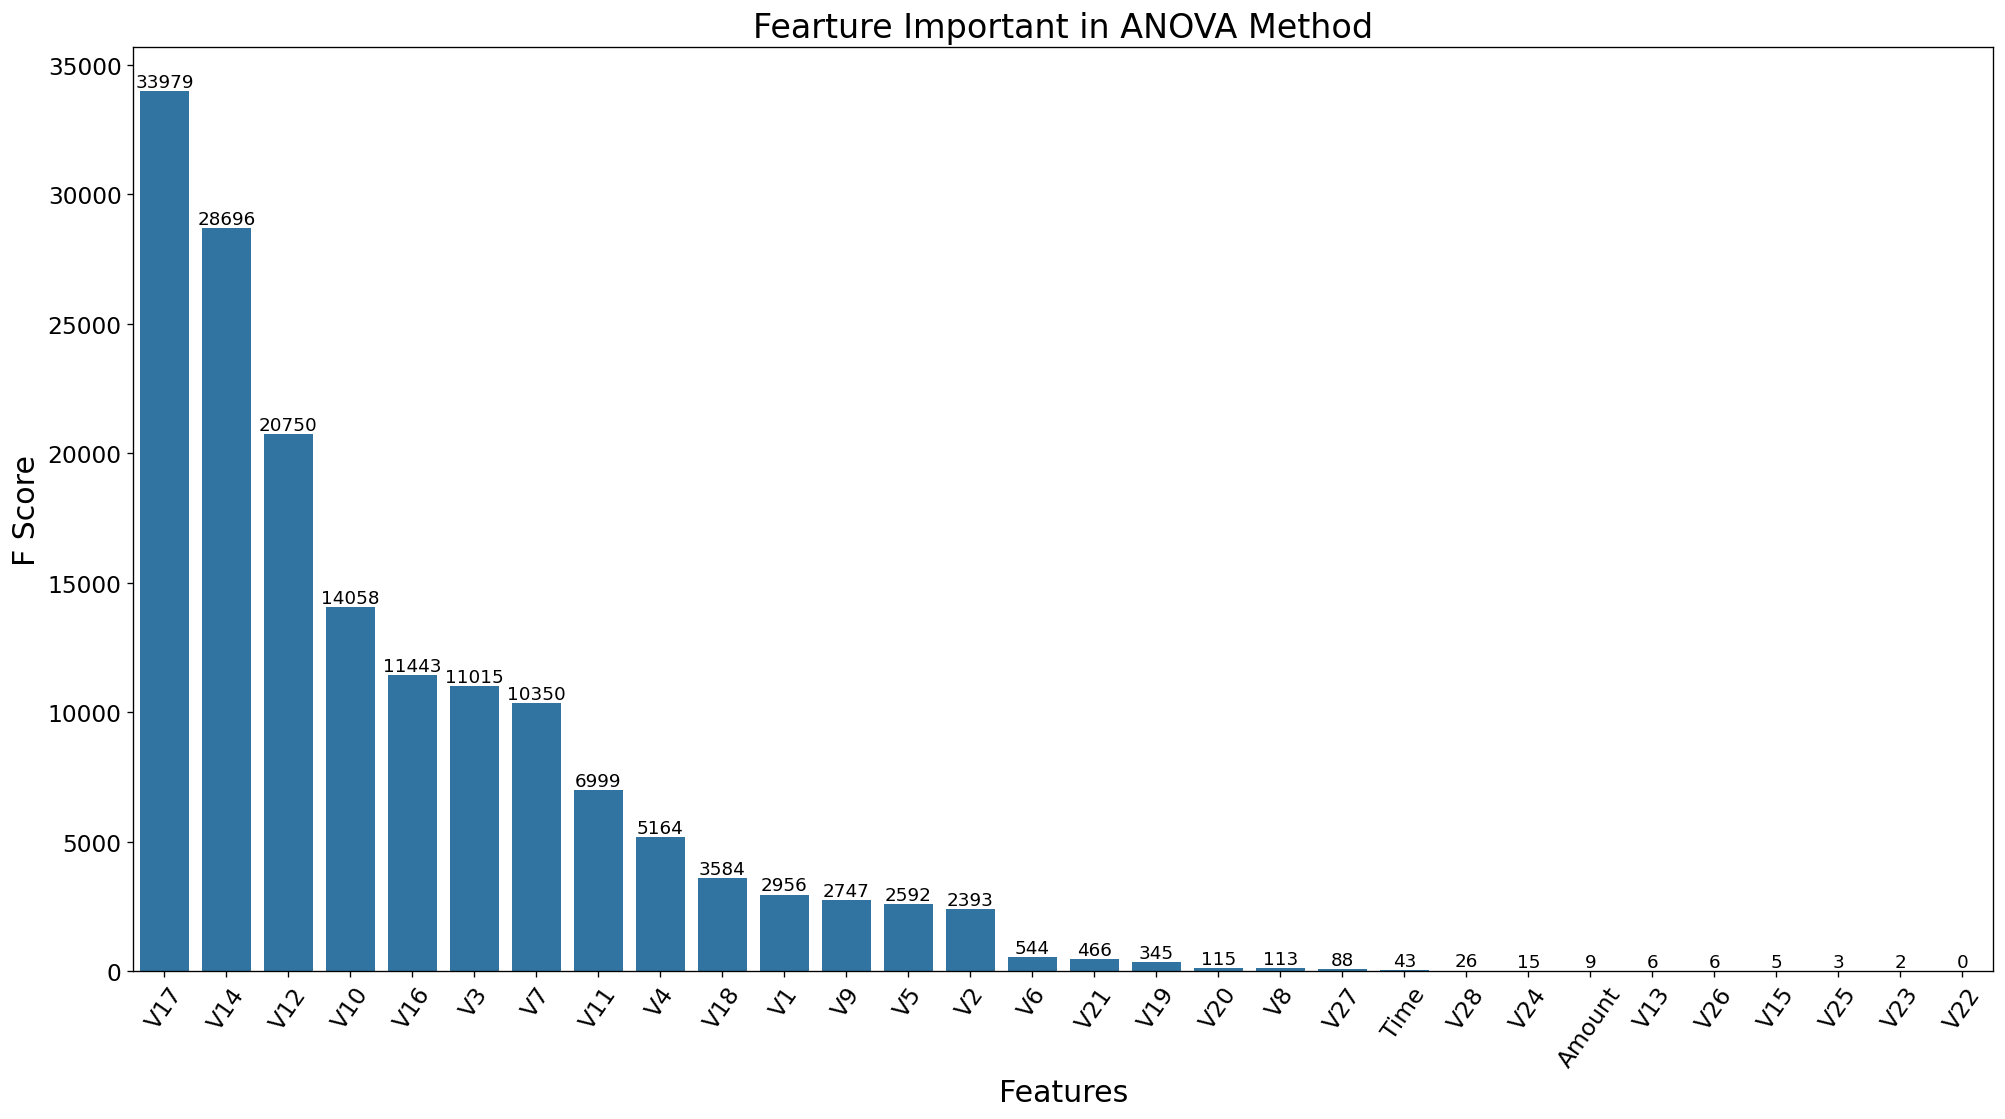

In [53]:
fig, ax = plt.subplots(figsize=(20,10), dpi=120)

sns.barplot(
    data=anova_df,
    x="Feature",
    y="F Score",
    ax=ax
)
plt.title("Fearture Important in ANOVA Method", fontsize=20)
plt.xlabel("Features", fontsize=18)
plt.ylabel("F Score", fontsize=18)
plt.tick_params(axis="both", labelsize=14)
ax.bar_label(
    ax.containers[0],
    fontsize=11,
    fmt="%.0f"
)

plt.xticks(rotation=55)
plt.savefig("../reports/figures/Fearture_Important_ANOVA.jpg")

plt.show()

📌 The ANOVA test results showed that features V17, V14, V12, V10 and V16 have the highest F-Score and P-value close to zero. These results indicate that the mean of these features is statistically significantly different between the Fraud and Normal classes. 

📌 Also, the overlap of these features with the Correlation and Mutual Information results confirms their importance as the most effective features of the dataset.

In [54]:
from sklearn.ensemble import RandomForestClassifier

In [55]:
clf = RandomForestClassifier(n_jobs=-1)

In [56]:
clf.fit(x, y.ravel())

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether boo

In [57]:
clf.feature_importances_

array([0.01340422, 0.0149111 , 0.01158217, 0.01781106, 0.03072358,
       0.01129583, 0.01490755, 0.02317609, 0.01122745, 0.03240821,
       0.06938386, 0.06233249, 0.11802931, 0.00986143, 0.09669605,
       0.01211064, 0.06555551, 0.21263543, 0.04555335, 0.01271678,
       0.01382451, 0.01717944, 0.01055494, 0.007383  , 0.01017747,
       0.00762608, 0.01553133, 0.01301613, 0.00828376, 0.01010125])

In [58]:
tree_base_important = (
    pd.DataFrame(
        {
            "Feature": df2.drop(columns=["Class"]).columns.to_list(),
            "feature importances": clf.feature_importances_,
        }
    )
    .reset_index(drop=True)
    .sort_values(by="feature importances", ascending=False)
)

In [59]:
tree_base_important.head()

,Feature,feature importances
17,V17,0.212635
12,V12,0.118029
14,V14,0.096696
10,V10,0.069384
16,V16,0.065556


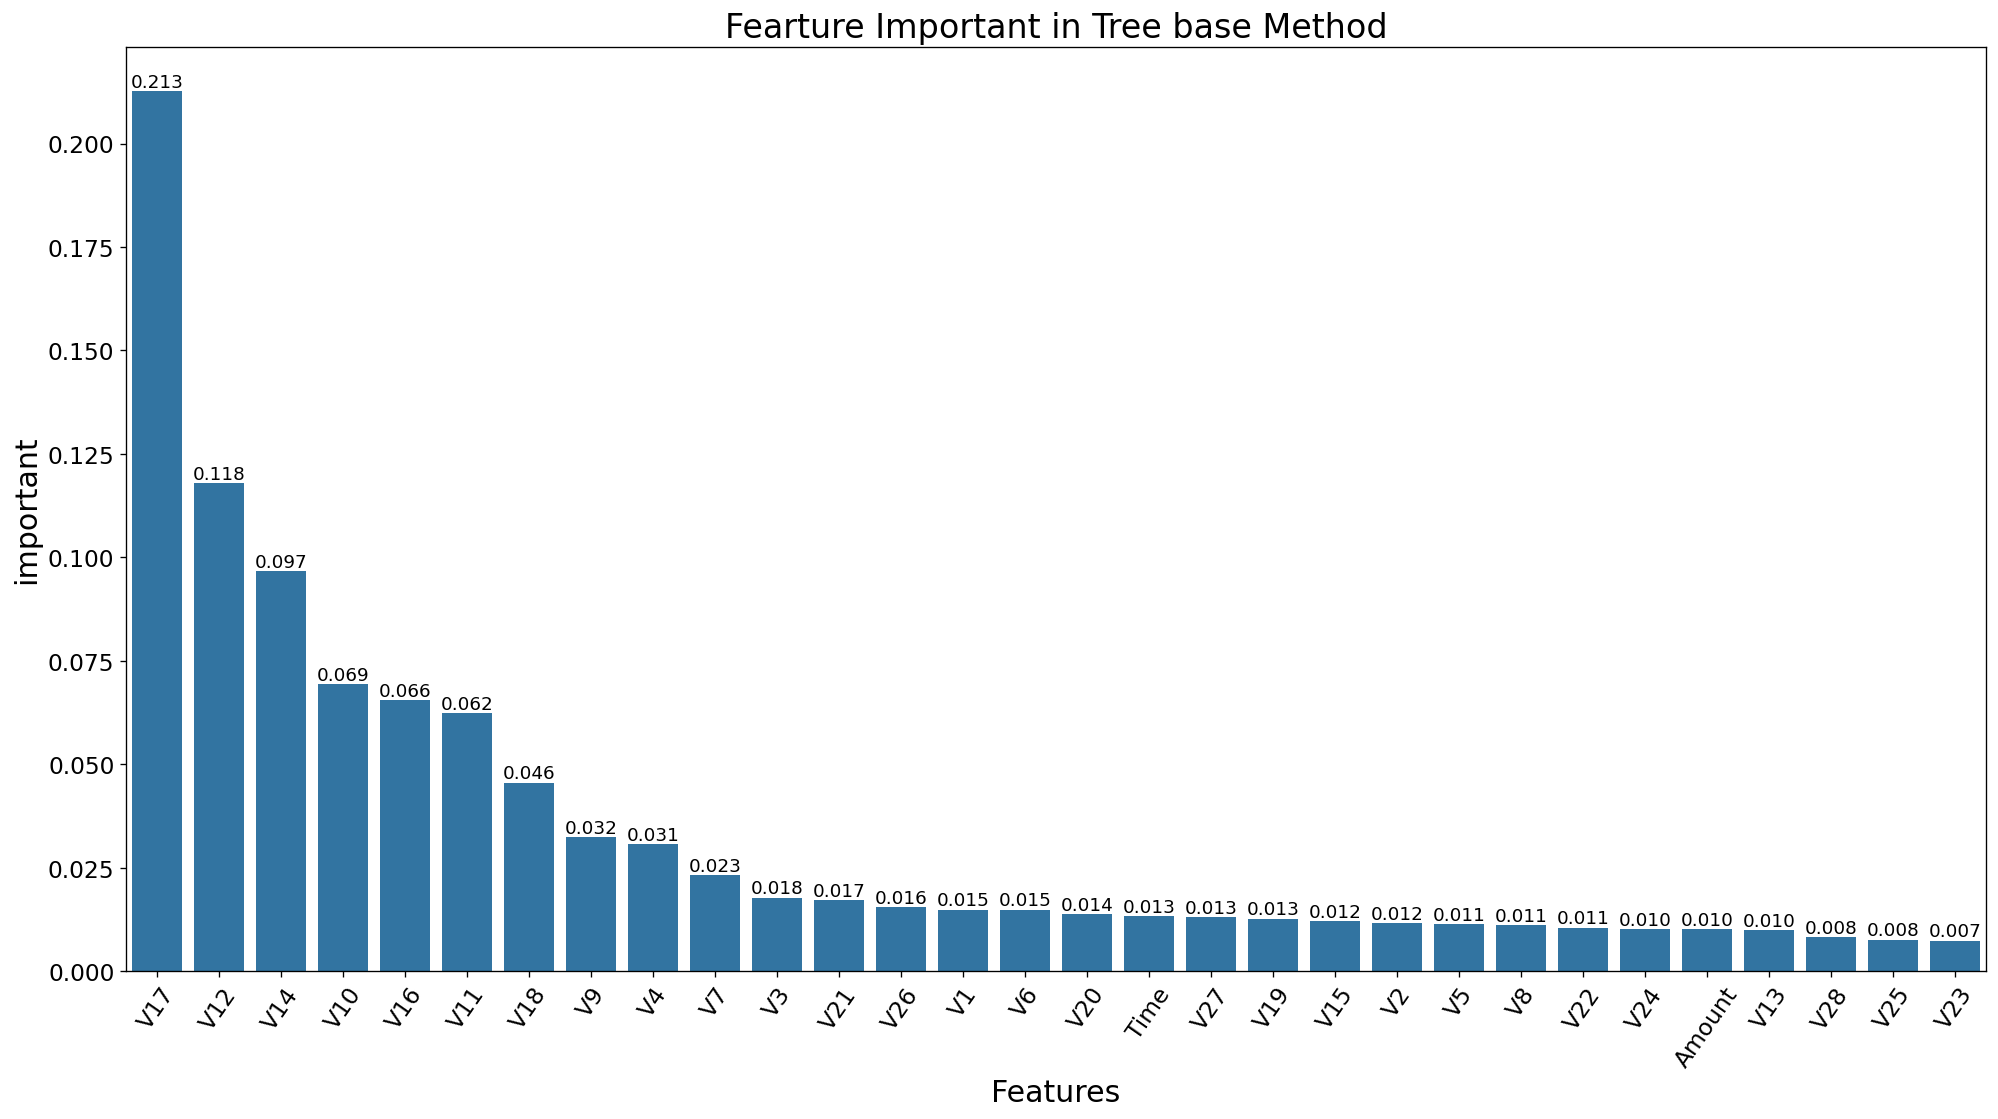

In [60]:
fig, ax = plt.subplots(figsize=(20,10), dpi=120)

sns.barplot(
    data=tree_base_important,
    x="Feature",
    y="feature importances",
    ax=ax
)
plt.title("Fearture Important in Tree base Method", fontsize=20)
plt.xlabel("Features", fontsize=18)
plt.ylabel("important", fontsize=18)
plt.tick_params(axis="both", labelsize=14)
ax.bar_label(
    ax.containers[0],
    fontsize=11,
    fmt="%.3f"
)

plt.xticks(rotation=55)
plt.savefig("../reports/figures/Fearture_Important_Tree_base.jpg")

plt.show()

## Overall Comparison of Feature Importance Methods

To identify the most influential features, four different feature selection techniques were applied:

- **Correlation Analysis**
- **Mutual Information**
- **ANOVA (F-test)**
- **Tree-Based Feature Importance**

The comparison of these methods is summarized below.

| Feature | Correlation | Mutual Information | ANOVA | Tree-Based | Overall Importance |
|---------|:-----------:|:------------------:|:------:|:----------:|:-----------------:|
| **V17** | ✅ | ✅ | ✅ | ✅ | ⭐⭐⭐⭐⭐ |
| **V14** | ✅ | ✅ | ✅ | ✅ | ⭐⭐⭐⭐⭐ |
| **V12** | ✅ | ✅ | ✅ | ✅ | ⭐⭐⭐⭐⭐ |
| **V10** | ✅ | ✅ | ✅ | ✅ | ⭐⭐⭐⭐⭐ |
| **V16** | ✅ | ✅ | ✅ | ✅ | ⭐⭐⭐⭐⭐ |
| **V11** | ✅ | ✅ | ⚪ | ✅ | ⭐⭐⭐⭐ |
| **V4**  | ✅ | ✅ | ⚪ | ✅ | ⭐⭐⭐⭐ |
| **V7**  | ✅ | ✅ | ⚪ | ✅ | ⭐⭐⭐⭐ |
| **V3**  | ✅ | ✅ | ⚪ | ✅ | ⭐⭐⭐⭐ |
| **V9**  | ✅ | ✅ | ⚪ | ✅ | ⭐⭐⭐⭐ |

### Legend

- ✅ Selected as an important feature by the method.
- ⚪ Not among the top features for that method.
- ⭐⭐⭐⭐⭐ = Extremely Important
- ⭐⭐⭐⭐ = Highly Important

---

## Top 10 Most Important Features

Based on the agreement across all feature selection techniques, the following ten features were consistently identified as the most informative:

| Rank | Feature | Supported By |
|-----:|---------|--------------|
| 1 | **V17** | Correlation, Mutual Information, ANOVA, Tree-Based |
| 2 | **V14** | Correlation, Mutual Information, ANOVA, Tree-Based |
| 3 | **V12** | Correlation, Mutual Information, ANOVA, Tree-Based |
| 4 | **V10** | Correlation, Mutual Information, ANOVA, Tree-Based |
| 5 | **V16** | Correlation, Mutual Information, ANOVA, Tree-Based |
| 6 | **V11** | Correlation, Mutual Information, Tree-Based |
| 7 | **V4**  | Correlation, Mutual Information, Tree-Based |
| 8 | **V7**  | Correlation, Mutual Information, Tree-Based |
| 9 | **V3**  | Correlation, Mutual Information, Tree-Based |
| 10 | **V9** | Correlation, Mutual Information, Tree-Based |

---

## Conclusion

The feature importance analysis using **Correlation**, **Mutual Information**, **ANOVA (F-test)**, and **Tree-Based Feature Importance** produced highly consistent results.

Among all features, **V17**, **V14**, **V12**, **V10**, and **V16** were consistently ranked as the most influential across all four methods. This strong agreement suggests that these features possess the highest discriminative power for distinguishing fraudulent transactions from legitimate ones.

Additionally, **V11**, **V4**, **V7**, **V3**, and **V9** were identified as highly informative by most of the applied methods, making them valuable complementary features for predictive modeling.

Overall, the consensus among multiple independent feature selection techniques increases confidence in the selected features. Therefore, the following features can be considered the most reliable candidates for downstream machine learning models:

> **V17, V14, V12, V10, V16, V11, V4, V7, V3, and V9.**

Although features such as **Time**, **Amount**, **V22**, **V23**, **V24**, **V25**, and **V26** received relatively low importance scores, they should not be removed solely based on univariate analyses. Some of these features may still contribute useful information through interactions captured by nonlinear models such as Random Forest, XGBoost, or LightGBM.

Let's move on to handling unbalanced data.

## Sampling methods

In [61]:
from imblearn.under_sampling import RandomUnderSampler

In [62]:
from sklearn.linear_model import LogisticRegression

In [63]:
from imblearn.pipeline import Pipeline as imb_pipeline

In [64]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [65]:
pipeline = imb_pipeline([
    ('scaler', scaler_transformer),
    ('randomundersampler', RandomUnderSampler(random_state=42)),
    ('model', LogisticRegression(random_state=42, n_jobs=-1, ))
])

In [66]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [67]:
scores = cross_validate(
    pipeline,
    x_train,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    return_train_score=True,
    n_jobs=-1
)


for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    train = scores[f"train_{metric}"].mean()
    test = scores[f"test_{metric}"].mean()

    print(f"{metric}")
    print(f"Train : {train:.4f}")
    print(f"Valid : {test:.4f}")
    print("-"*30)

accuracy
Train : 0.9610
Valid : 0.9609
------------------------------
precision
Train : 0.0402
Valid : 0.0400
------------------------------
recall
Train : 0.9277
Valid : 0.9188
------------------------------
f1
Train : 0.0770
Valid : 0.0765
------------------------------
roc_auc
Train : 0.9871
Valid : 0.9730
------------------------------


In [73]:
from imblearn.over_sampling import RandomOverSampler

In [74]:
pipeline2 = imb_pipeline([
    ('scaler', scaler_transformer),
    ('random_over_sampler', RandomOverSampler(random_state=42)),
    ('model', LogisticRegression(random_state=42, n_jobs=-1, ))
])

In [78]:
scores2 = cross_validate(
    pipeline2,
    x_train,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    return_train_score=True,
    n_jobs=-1
)

print("Results for RandomOverSampler")
for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    train = scores2[f"train_{metric}"].mean()
    test = scores2[f"test_{metric}"].mean()

    print(f"{metric}")
    print(f"Train : {train:.4f}")
    print(f"Valid : {test:.4f}")
    print("-"*30)

Results for RandomOverSampler
accuracy
Train : 0.9761
Valid : 0.9763
------------------------------
precision
Train : 0.0629
Valid : 0.0624
------------------------------
recall
Train : 0.9188
Valid : 0.9036
------------------------------
f1
Train : 0.1177
Valid : 0.1167
------------------------------
roc_auc
Train : 0.9895
Valid : 0.9776
------------------------------


In [76]:
from imblearn.over_sampling import SMOTE

In [80]:
pipeline3 = imb_pipeline([
    ('scaler', scaler_transformer),
    ('smote', SMOTE(random_state=42, k_neighbors=10)),
    ('model', LogisticRegression(random_state=42, n_jobs=-1, ))
])

In [82]:
scores3 = cross_validate(
    pipeline3,
    x_train,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    return_train_score=True,
    n_jobs=-1
)

print("Results for SMOTE")
for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    train = scores3[f"train_{metric}"].mean()
    test = scores3[f"test_{metric}"].mean()

    print(f"{metric}")
    print(f"Train : {train:.4f}")
    print(f"Valid : {test:.4f}")
    print("-"*30)

Results for SMOTE
accuracy
Train : 0.9748
Valid : 0.9750
------------------------------
precision
Train : 0.0600
Valid : 0.0589
------------------------------
recall
Train : 0.9213
Valid : 0.8935
------------------------------
f1
Train : 0.1126
Valid : 0.1105
------------------------------
roc_auc
Train : 0.9889
Valid : 0.9747
------------------------------


In [94]:
from imblearn.over_sampling import ADASYN

In [95]:
pipeline4 = imb_pipeline([
    ('scaler', scaler_transformer),
    ('ADASYN', ADASYN(random_state=42)),
    ('model', LogisticRegression(random_state=42, n_jobs=-1, ))
])

In [96]:
scores4 = cross_validate(
    pipeline4,
    x_train,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    return_train_score=True,
    n_jobs=-1
)

print("Results for ADASYN")
for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    train = scores4[f"train_{metric}"].mean()
    test = scores4[f"test_{metric}"].mean()

    print(f"{metric}")
    print(f"Train : {train:.4f}")
    print(f"Valid : {test:.4f}")
    print("-"*30)

Results for ADASYN
accuracy
Train : 0.9261
Valid : 0.9265
------------------------------
precision
Train : 0.0219
Valid : 0.0214
------------------------------
recall
Train : 0.9537
Valid : 0.9239
------------------------------
f1
Train : 0.0428
Valid : 0.0418
------------------------------
roc_auc
Train : 0.9894
Valid : 0.9718
------------------------------


In [97]:
from imblearn.under_sampling import NeighbourhoodCleaningRule

In [99]:
pipeline5 = imb_pipeline([
    ('scaler', scaler_transformer),
    (
        'Under_sampeler_NeighbourhoodCleaningRule', 
        NeighbourhoodCleaningRule(n_jobs=-1, n_neighbors=5)
        ),
    ('model', LogisticRegression(random_state=42, n_jobs=-1, ))
])

In [101]:
scores5 = cross_validate(
    pipeline5,
    x_train,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    return_train_score=True,
    n_jobs=-1
)

print("Results for NeighbourhoodCleaningRule")
for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    train = scores5[f"train_{metric}"].mean()
    test = scores5[f"test_{metric}"].mean()

    print(f"{metric}")
    print(f"Train : {train:.4f}")
    print(f"Valid : {test:.4f}")
    print("-"*30)

Results for NeighbourhoodCleaningRule
accuracy
Train : 0.9993
Valid : 0.9993
------------------------------
precision
Train : 0.8754
Valid : 0.8704
------------------------------
recall
Train : 0.7030
Valid : 0.6805
------------------------------
f1
Train : 0.7793
Valid : 0.7602
------------------------------
roc_auc
Train : 0.9828
Valid : 0.9794
------------------------------


In [113]:
from sklearn.pipeline import Pipeline

In [114]:
preprocessor = Pipeline([
    ('scaler', scaler_transformer),
    ('Under_sampeler_NeighbourhoodCleaningRule',
     NeighbourhoodCleaningRule(n_jobs=-1, n_neighbors=5)
    )
])